# 딥러닝 응용 - 시계열 예측 RNN과 LSTM

## 학습 목표

1. **RNN 구조 이해** 순환 신경망의 구조와 시퀀스 데이터 처리 원리를 이해함
2. **LSTM/GRU 원리** 게이트 구조로 장기 의존성 문제를 해결하는 방법을 학습함
3. **Keras 구현** LSTM 모델을 Keras로 구성하고 학습함
4. **RUL 예측** NASA C-MAPSS 터보팬 엔진 데이터로 잔여수명(RUL)을 예측함

## 실습 데이터셋: NASA C-MAPSS

### 데이터셋 소개

| 항목 | 내용 |
|------|------|
| 데이터명 | NASA C-MAPSS (Commercial Modular Aero-Propulsion System Simulation) |
| 출처 | NASA Prognostics Center of Excellence |
| 용도 | 터보팬 엔진의 잔여수명(Remaining Useful Life, RUL) 예측 |
| 특징 | 다변량 시계열, 센서 21개, 운전 조건 3개 |

### 데이터셋 구성

C-MAPSS 데이터셋은 4개의 서브셋(FD001~FD004)으로 구성되어 있음. 본 실습에서는 가장 기본적인 FD001을 사용함.

| 데이터셋 | 학습 엔진 수 | 테스트 엔진 수 | 운전 조건 | 고장 모드 |
|----------|------------|--------------|----------|----------|
| FD001 | 100 | 100 | 1 (해수면) | 1 (HPC 열화) |
| FD002 | 260 | 259 | 6 | 1 |
| FD003 | 100 | 100 | 1 | 2 |
| FD004 | 248 | 249 | 6 | 2 |

### 컬럼 구성

```
컬럼 1     : unit_id (엔진 번호)
컬럼 2     : cycle (운전 사이클, 시간 인덱스)
컬럼 3-5   : op_setting_1~3 (운전 설정값)
컬럼 6-26  : sensor_1~21 (센서 측정값)
```

### 센서 설명

| 센서 | 설명 | 단위 |
|------|------|------|
| sensor_2 | 총 온도 (T2) - LPC 출구 | R (Rankine) |
| sensor_3 | 총 온도 (T24) - LPC 출구 | R |
| sensor_4 | 총 온도 (T30) - HPC 출구 | R |
| sensor_7 | 총 압력 (P30) - HPC 출구 | psia |
| sensor_11 | 정적 압력 (Ps30) - HPC 출구 | psia |
| sensor_12 | 연료-공기 비율 (phi) | - |
| sensor_15 | 바이패스 비율 | - |
| sensor_21 | 코어 속도 (Nf) | rpm |

### 예지정비(Predictive Maintenance)의 중요성

제조 현장에서 설비의 갑작스러운 고장은 막대한 비용 손실을 초래함. 예지정비는 센서 데이터를 분석하여 고장을 사전에 예측하고, 최적의 시점에 정비를 수행하는 기술임.

```mermaid
graph LR
    A[센서 데이터 수집] --> B[시계열 분석]
    B --> C[RUL 예측 모델]
    C --> D{잔여수명 판단}
    D -->|충분| E[정상 운전]
    D -->|부족| F[정비 스케줄링]
    F --> G[예방 정비 수행]
    G --> A
```

## 1: RNN 기초 - 순환 구조와 시퀀스 처리

### 1.1 시퀀스 데이터란?

시퀀스 데이터(Sequence Data)는 **순서가 의미를 가지는 데이터**임. 데이터의 순서를 바꾸면 전혀 다른 의미가 되거나 정보가 손실됨.

#### 시퀀스 데이터의 예시

| 분야 | 예시 | 순서의 의미 |
|------|------|------------|
| 제조 | 센서 시계열 | 시간에 따른 설비 상태 변화 |
| 자연어 | 문장 | 단어 순서가 문법과 의미 결정 |
| 금융 | 주가 | 시간에 따른 가격 흐름 |
| 음성 | 음파 | 시간에 따른 소리 변화 |

#### 왜 MLP(다층 퍼셉트론)로는 부족한가?

일반적인 MLP는 입력을 **독립적인 특성 벡터**로 처리함. 즉, 각 입력 샘플이 서로 독립이라고 가정함.

그러나 시계열 데이터에서는 **이전 시점의 정보가 현재에 영향**을 미침.

예를 들어, 터보팬 엔진의 온도가 다음과 같이 변했다고 가정:

```
시점 1: 온도 = 500K (정상)
시점 2: 온도 = 505K (정상)
시점 3: 온도 = 520K (상승 추세?)
시점 4: 온도 = 540K (경고!)
```

시점 4의 540K만 보면 단순히 "높은 온도"일 뿐이지만, **시점 1~3의 상승 추세**를 함께 보면 "급격한 온도 상승 중"이라는 위험 신호로 해석할 수 있음.

RNN은 이러한 **시간적 패턴(Temporal Pattern)** 을 학습할 수 있는 구조임.
> 참고로, 우리가 이전 차시에서 다룬 CNN은 **공간적 패턴(Locality)** 을 다루었었음.

일반 데이터 vs 시퀀스 데이터 비교

[일반 데이터 - MLP 입력]
  특징: 각 샘플이 독립적이며, 순서를 바꿔도 학습 결과 동일
  예시: 제품의 크기, 무게, 색상 -> 양품/불량 분류
        샘플1: [10.2, 5.3, 0.8] -> 양품
        샘플2: [10.5, 5.1, 0.9] -> 양품
        (순서 바꿔도 각 샘플의 라벨 동일)

[시퀀스 데이터 - RNN 입력]
  특징: 이전 시점의 정보가 현재 예측에 영향
  예시: 엔진 온도 시계열 -> 고장 예측

  정상 패턴: [500, 502, 501, 503, 500, 502] -> 안정적, 고장 확률 낮음
  이상 패턴: [500, 505, 520, 540, 565, 600] -> 급상승, 고장 임박


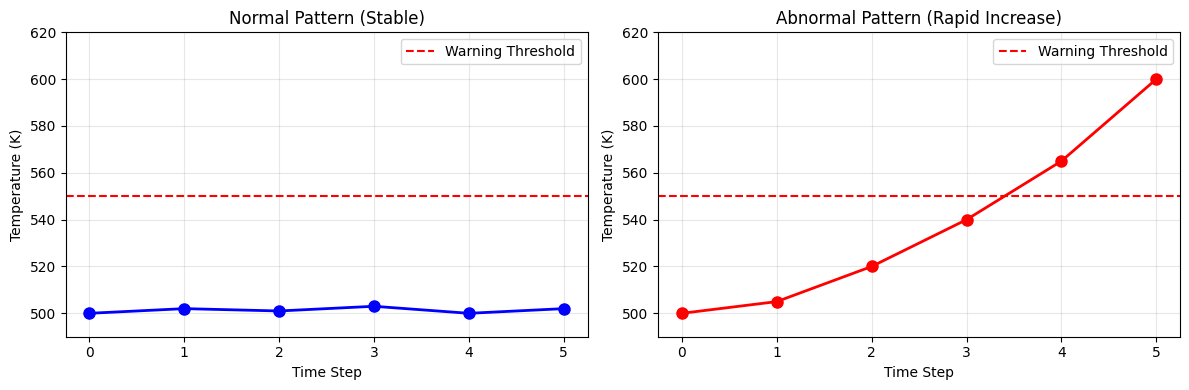


[핵심 포인트]
  MLP는 시점 6의 값만 보고 판단: 500K(정상) vs 600K(이상) -> 둘 다 높거나 낮을 뿐
  RNN은 시점 1~6의 '추세'를 보고 판단: 안정 vs 급상승 -> 패턴 인식 가능


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 시퀀스 데이터의 특성 시각화
print("=" * 70)
print("일반 데이터 vs 시퀀스 데이터 비교")
print("=" * 70)

# 일반 데이터 예시 (순서 무관)
print("\n[일반 데이터 - MLP 입력]")
print("  특징: 각 샘플이 독립적이며, 순서를 바꿔도 학습 결과 동일")
print("  예시: 제품의 크기, 무게, 색상 -> 양품/불량 분류")
print("        샘플1: [10.2, 5.3, 0.8] -> 양품")
print("        샘플2: [10.5, 5.1, 0.9] -> 양품")
print("        (순서 바꿔도 각 샘플의 라벨 동일)")

# 시퀀스 데이터 예시 (순서 중요)
print("\n[시퀀스 데이터 - RNN 입력]")
print("  특징: 이전 시점의 정보가 현재 예측에 영향")
print("  예시: 엔진 온도 시계열 -> 고장 예측")

# 예시 데이터 생성
normal_sequence = [500, 502, 501, 503, 500, 502]  # 정상 패턴
abnormal_sequence = [500, 505, 520, 540, 565, 600]  # 이상 패턴

print("\n  정상 패턴:", normal_sequence, "-> 안정적, 고장 확률 낮음")
print("  이상 패턴:", abnormal_sequence, "-> 급상승, 고장 임박")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(normal_sequence, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Normal Pattern (Stable)', fontsize=12)
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Temperature (K)')
axes[0].set_ylim([490, 620])
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=550, color='r', linestyle='--', label='Warning Threshold')
axes[0].legend()

axes[1].plot(abnormal_sequence, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Abnormal Pattern (Rapid Increase)', fontsize=12)
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Temperature (K)')
axes[1].set_ylim([490, 620])
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=550, color='r', linestyle='--', label='Warning Threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('sequence_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[핵심 포인트]")
print("  MLP는 시점 6의 값만 보고 판단: 500K(정상) vs 600K(이상) -> 둘 다 높거나 낮을 뿐")
print("  RNN은 시점 1~6의 '추세'를 보고 판단: 안정 vs 급상승 -> 패턴 인식 가능")

### 1.2 RNN의 핵심 아이디어: 순환 구조

RNN(Recurrent Neural Network, 순환 신경망)의 핵심은 **은닉 상태(Hidden State)** 를 통해 이전 시점의 정보를 현재 시점으로 전달하는 것임.

#### RNN 기본 수식

시점 $t$에서 RNN 셀의 동작은 다음 수식으로 표현됨:

$$
h_t = \tanh(W_h h_{t-1} + W_x x_t + b)
$$

| 기호 | 의미 | 차원 예시 |
|------|------|----------|
| $x_t$ | 시점 $t$의 입력 벡터 | (input_dim,) |
| $h_t$ | 시점 $t$의 은닉 상태 | (hidden_dim,) |
| $h_{t-1}$ | 이전 시점의 은닉 상태 | (hidden_dim,) |
| $W_x$ | 입력에 대한 가중치 행렬 | (hidden_dim, input_dim) |
| $W_h$ | 은닉 상태에 대한 가중치 행렬 | (hidden_dim, hidden_dim) |
| $b$ | 편향 벡터 | (hidden_dim,) |
| $\tanh$ | 활성화 함수 (출력 범위: -1 ~ 1) | - |

#### 왜 tanh를 사용하는가?

tanh (하이퍼볼릭 탄젠트) 함수의 수식:

$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$

| 활성화 함수 | 출력 범위 | 장점 | 단점 |
|------------|----------|------|------|
| sigmoid | 0 ~ 1 | 확률 해석 가능 | 출력이 항상 양수, 기울기 소실 |
| tanh | -1 ~ 1 | 음수/양수 표현, 0 중심 | 기울기 소실 (sigmoid보다는 나음) |
| ReLU | 0 ~ 무한대 | 기울기 소실 완화 | RNN에서는 값 폭발 가능 |

tanh는 **0을 중심**으로 출력하여 다음 층의 학습을 안정화시키고, **음수와 양수**를 모두 표현할 수 있어 RNN에 적합함.

In [2]:
def tanh(x):
    """하이퍼볼릭 탄젠트 함수"""
    return np.tanh(x)

def simple_rnn_cell(x_t, h_prev, W_h, W_x, b):
    """
    단순 RNN 셀의 순전파
    
    수식: h_t = tanh(W_h * h_{t-1} + W_x * x_t + b)
    
    Parameters:
        x_t    : 현재 시점의 입력 (input_dim,)
        h_prev : 이전 시점의 은닉 상태 (hidden_dim,)
        W_h    : 은닉 상태 가중치 (hidden_dim, hidden_dim)
        W_x    : 입력 가중치 (hidden_dim, input_dim)
        b      : 편향 (hidden_dim,)
    
    Returns:
        h_t    : 현재 시점의 은닉 상태 (hidden_dim,)
    """
    # 선형 변환
    linear_h = np.dot(W_h, h_prev)  # 이전 은닉 상태의 기여
    linear_x = np.dot(W_x, x_t)     # 현재 입력의 기여
    linear_sum = linear_h + linear_x + b
    
    # 비선형 활성화
    h_t = tanh(linear_sum)
    
    return h_t

def simple_rnn_forward(X_sequence, W_h, W_x, b):
    """
    전체 시퀀스에 대한 RNN 순전파
    
    Parameters:
        X_sequence : 입력 시퀀스 (seq_len, input_dim)
        W_h, W_x, b: RNN 파라미터
    
    Returns:
        hidden_states : 모든 시점의 은닉 상태 (seq_len, hidden_dim)
    """
    seq_len = len(X_sequence)
    hidden_dim = W_h.shape[0]
    
    # 은닉 상태 초기화 (0 벡터)
    h_prev = np.zeros(hidden_dim)
    hidden_states = []
    
    print("RNN 순전파 과정:")
    print("-" * 60)
    print(f"{'시점':^6} {'입력 x_t':^15} {'이전 h_{t-1}':^20} {'현재 h_t':^20}")
    print("-" * 60)
    
    for t, x_t in enumerate(X_sequence):
        h_t = simple_rnn_cell(x_t, h_prev, W_h, W_x, b)
        
        # 출력 (첫 번째 원소만 표시)
        print(f"t={t:2d}    x={x_t[0]:8.3f}       h_prev={h_prev[0]:8.4f}        h_t={h_t[0]:8.4f}")
        
        hidden_states.append(h_t)
        h_prev = h_t  # 현재 상태를 다음 시점의 '이전 상태'로
    
    print("-" * 60)
    return np.array(hidden_states)

# 예시: 간단한 RNN 동작
print("=" * 70)
print("RNN 셀 동작 시뮬레이션")
print("=" * 70)

np.random.seed(42)

# 하이퍼파라미터
input_dim = 1    # 입력 차원 (온도 1개)
hidden_dim = 4   # 은닉 상태 차원

# 파라미터 초기화 (Xavier 초기화 유사)
W_h = np.random.randn(hidden_dim, hidden_dim) * 0.5
W_x = np.random.randn(hidden_dim, input_dim) * 0.5
b = np.zeros(hidden_dim)

# 센서 데이터 시퀀스 (온도, 정규화됨)
temperature_seq = np.array([[0.1], [0.15], [0.25], [0.4], [0.6], [0.8]])  # 상승 추세
print(f"\n입력 시퀀스 (정규화된 온도): {temperature_seq.flatten()}")
print(f"해석: 온도가 점진적으로 상승하는 패턴\n")

# 순전파 실행
hidden_states = simple_rnn_forward(temperature_seq, W_h, W_x, b)

print(f"\n최종 은닉 상태 h_T: {hidden_states[-1]}")
print("\n[해석]")
print("  - 최종 은닉 상태는 전체 시퀀스의 정보가 '압축'된 벡터")
print("  - 이 벡터를 통해 '온도 상승 추세'라는 패턴이 인코딩됨")
print("  - 이후 Dense 층을 통해 RUL(잔여수명) 예측에 활용")

RNN 셀 동작 시뮬레이션

입력 시퀀스 (정규화된 온도): [0.1  0.15 0.25 0.4  0.6  0.8 ]
해석: 온도가 점진적으로 상승하는 패턴

RNN 순전파 과정:
------------------------------------------------------------
  시점       입력 x_t           이전 h_{t-1}             현재 h_t       
------------------------------------------------------------
t= 0    x=   0.100       h_prev=  0.0000        h_t= -0.0506
t= 1    x=   0.150       h_prev= -0.0506        h_t= -0.1567
t= 2    x=   0.250       h_prev= -0.1567        h_t= -0.2194
t= 3    x=   0.400       h_prev= -0.2194        h_t= -0.3547
t= 4    x=   0.600       h_prev= -0.3547        h_t= -0.5324
t= 5    x=   0.800       h_prev= -0.5324        h_t= -0.6700
------------------------------------------------------------

최종 은닉 상태 h_T: [-0.66995746 -0.02264602 -0.14210819 -0.40027618]

[해석]
  - 최종 은닉 상태는 전체 시퀀스의 정보가 '압축'된 벡터
  - 이 벡터를 통해 '온도 상승 추세'라는 패턴이 인코딩됨
  - 이후 Dense 층을 통해 RUL(잔여수명) 예측에 활용


### 1.3 RNN의 구조 시각화

RNN은 두 가지 방식으로 시각화할 수 있음:

1. **접힌 표현(Folded View)**: 하나의 셀이 자기 자신으로 순환
2. **펼친 표현(Unfolded View)**: 시간에 따라 셀을 복사하여 표현

```mermaid
graph LR
    subgraph "Unfolded RNN"
        x0[x_0] --> RNN0[RNN]
        x1[x_1] --> RNN1[RNN]
        x2[x_2] --> RNN2[RNN]
        x3["..."] --> RNN3[RNN]
        xT[x_T] --> RNNT[RNN]
        
        RNN0 -->|h_0| RNN1
        RNN1 -->|h_1| RNN2
        RNN2 -->|h_2| RNN3
        RNN3 -->|"..."| RNNT
        
        RNNT -->|h_T| output[Output]
    end
```

중요한 점은 **모든 시점에서 동일한 가중치(W_h, W_x, b)** 를 공유한다는 것임. 이를 **가중치 공유(Weight Sharing)** 라고 하며, 파라미터 수를 줄이고 시퀀스 길이에 관계없이 동일한 모델을 적용할 수 있게 함.

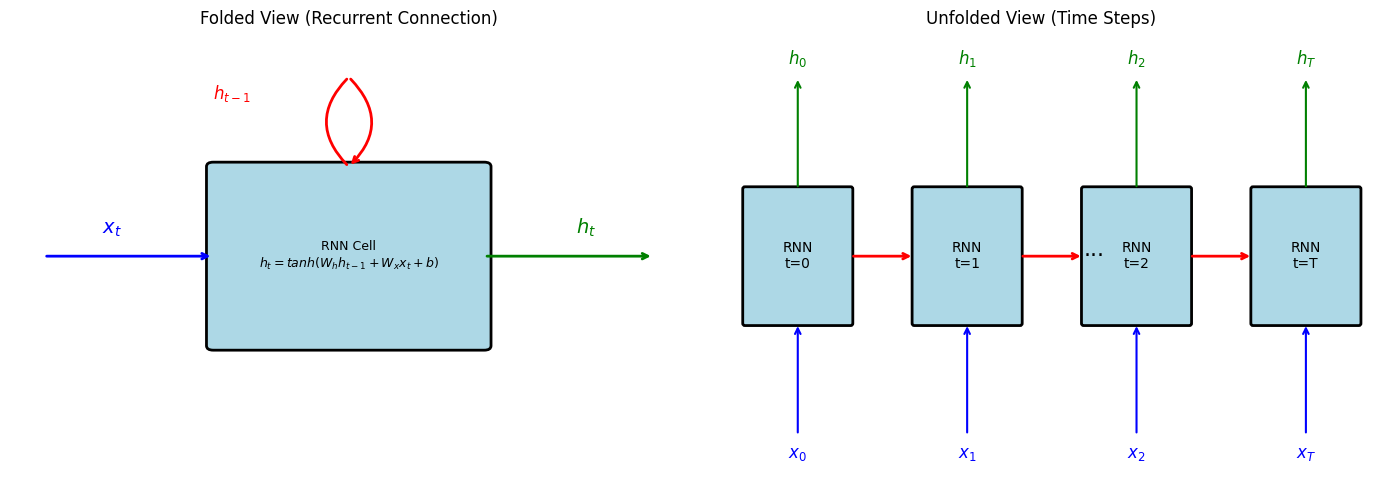

[RNN 구조 핵심 포인트]
  1. 모든 시점에서 동일한 파라미터 (W_h, W_x, b) 공유
  2. 은닉 상태 h_t가 '기억' 역할 수행
  3. 최종 은닉 상태 h_T가 전체 시퀀스 정보를 담음


In [3]:
# RNN 구조 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: Folded View
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)

# RNN 셀 박스
from matplotlib.patches import Rectangle, FancyArrowPatch, FancyBboxPatch

rect = FancyBboxPatch((3, 3), 4, 4, boxstyle="round,pad=0.1", 
                       facecolor='lightblue', edgecolor='black', linewidth=2)
ax1.add_patch(rect)
ax1.text(5, 5, 'RNN Cell\n$h_t = tanh(W_h h_{t-1} + W_x x_t + b)$',
         ha='center', va='center', fontsize=9)

# 입력 화살표
ax1.annotate('', xy=(3, 5), xytext=(0.5, 5),
            arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
ax1.text(1.5, 5.5, '$x_t$', fontsize=14, ha='center', color='blue')

# 출력 화살표
ax1.annotate('', xy=(9.5, 5), xytext=(7, 5),
            arrowprops=dict(arrowstyle='->', lw=2, color='green'))
ax1.text(8.5, 5.5, '$h_t$', fontsize=14, ha='center', color='green')

# 순환 화살표
ax1.annotate('', xy=(5, 7), xytext=(5, 9),
            arrowprops=dict(arrowstyle='->', lw=2, color='red',
                           connectionstyle="arc3,rad=-0.5"))
ax1.annotate('', xy=(5, 9), xytext=(5, 7),
            arrowprops=dict(arrowstyle='-', lw=2, color='red',
                           connectionstyle="arc3,rad=-0.5"))
ax1.text(3, 8.5, '$h_{t-1}$', fontsize=12, color='red')

ax1.set_title('Folded View (Recurrent Connection)', fontsize=12)
ax1.axis('off')

# 오른쪽: Unfolded View
ax2 = axes[1]
ax2.set_xlim(0, 16)
ax2.set_ylim(0, 10)

# 4개 시점 표현
for i, t in enumerate([0, 1, 2, 'T']):
    x_pos = 1 + i * 4
    
    # RNN 셀 박스
    rect = FancyBboxPatch((x_pos, 3.5), 2.5, 3, boxstyle="round,pad=0.05",
                          facecolor='lightblue', edgecolor='black', linewidth=2)
    ax2.add_patch(rect)
    ax2.text(x_pos + 1.25, 5, f'RNN\nt={t}', ha='center', va='center', fontsize=10)
    
    # 입력 화살표
    ax2.annotate('', xy=(x_pos + 1.25, 3.5), xytext=(x_pos + 1.25, 1),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='blue'))
    ax2.text(x_pos + 1.25, 0.5, f'$x_{{{t}}}$', fontsize=12, ha='center', color='blue')
    
    # 출력 화살표
    ax2.annotate('', xy=(x_pos + 1.25, 9), xytext=(x_pos + 1.25, 6.5),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='green'))
    ax2.text(x_pos + 1.25, 9.3, f'$h_{{{t}}}$', fontsize=12, ha='center', color='green')
    
    # 은닉 상태 전달 (순환)
    if i < 3:
        ax2.annotate('', xy=(x_pos + 4, 5), xytext=(x_pos + 2.5, 5),
                    arrowprops=dict(arrowstyle='->', lw=2, color='red'))

# '...' 추가
ax2.text(9.25, 5, '...', fontsize=16, ha='center')

ax2.set_title('Unfolded View (Time Steps)', fontsize=12)
ax2.axis('off')

plt.tight_layout()
plt.savefig('rnn_structure.png', dpi=150, bbox_inches='tight')
plt.show()

print("[RNN 구조 핵심 포인트]")
print("  1. 모든 시점에서 동일한 파라미터 (W_h, W_x, b) 공유")
print("  2. 은닉 상태 h_t가 '기억' 역할 수행")
print("  3. 최종 은닉 상태 h_T가 전체 시퀀스 정보를 담음")

### 1.4 기울기 소실 문제 (Vanishing Gradient Problem)

RNN의 가장 큰 문제는 **긴 시퀀스에서 초기 정보가 소실**되는 것임.

#### 수학적 배경

역전파(Backpropagation Through Time, BPTT) 시, 손실 함수 $L$에 대한 초기 은닉 상태 $h_0$의 기울기는:

$$
\frac{\partial L}{\partial h_0} = \frac{\partial L}{\partial h_T} \cdot \frac{\partial h_T}{\partial h_{T-1}} \cdot \frac{\partial h_{T-1}}{\partial h_{T-2}} \cdots \frac{\partial h_1}{\partial h_0}
$$

각 $\frac{\partial h_t}{\partial h_{t-1}}$는:

$$
\frac{\partial h_t}{\partial h_{t-1}} = W_h^T \cdot \text{diag}(1 - h_t^2)
$$

여기서 $(1 - h_t^2)$는 tanh의 도함수이며, 최대값이 1임.

#### 문제점

만약 $\|W_h\| < 1$이면, 여러 시점을 거치며 기울기가 **지수적으로 감소**함:

$$
\left\| \frac{\partial L}{\partial h_0} \right\| \approx \|W_h\|^T \cdot \left\| \frac{\partial L}{\partial h_T} \right\| \rightarrow 0 \quad (\text{as } T \rightarrow \infty)
$$

반대로 $\|W_h\| > 1$이면 **기울기 폭발(Exploding Gradient)**이 발생함.

기울기 소실/폭발 문제 시뮬레이션


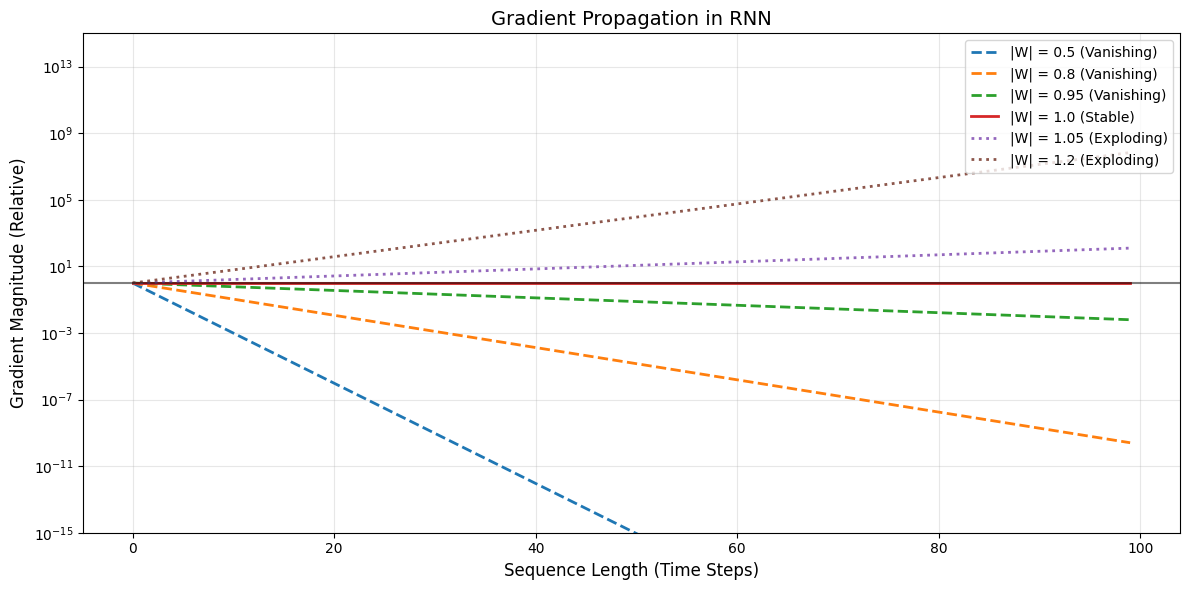


[시퀀스 길이별 기울기 크기 (|W| = 0.8 기준)]
--------------------------------------------------
  T =  10: 기울기 크기 = 1.07e-01
  T =  25: 기울기 크기 = 3.78e-03
  T =  50: 기울기 크기 = 1.43e-05
  T = 100: 기울기 크기 = 2.04e-10

[결론]
  - 시퀀스가 길어질수록 초기 입력의 기울기가 거의 0에 수렴
  - 초기 시점의 정보가 학습에 반영되지 않음
  - 해결책: LSTM, GRU의 게이트 메커니즘


In [4]:
def demonstrate_vanishing_gradient():
    """
    기울기 소실 문제 시뮬레이션
    
    역전파 시 기울기 크기 변화를 시각화
    """
    print("=" * 70)
    print("기울기 소실/폭발 문제 시뮬레이션")
    print("=" * 70)
    
    # 가중치 행렬의 스펙트럼 반경(최대 고유값 크기)에 따른 기울기 변화
    # 단순화: 스칼라 가중치로 시뮬레이션
    
    gradient_scales = [0.5, 0.8, 0.95, 1.0, 1.05, 1.2]
    sequence_length = 100
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for scale in gradient_scales:
        # 기울기 크기 변화 (T 시점에서 0 시점으로)
        gradients = [scale ** t for t in range(sequence_length)]
        label = f'|W| = {scale}'
        
        if scale < 1:
            style = '--'
            label += ' (Vanishing)'
        elif scale > 1:
            style = ':'
            label += ' (Exploding)'
        else:
            style = '-'
            label += ' (Stable)'
        
        ax.plot(gradients, style, label=label, linewidth=2)
    
    ax.set_xlabel('Sequence Length (Time Steps)', fontsize=12)
    ax.set_ylabel('Gradient Magnitude (Relative)', fontsize=12)
    ax.set_title('Gradient Propagation in RNN', fontsize=14)
    ax.set_yscale('log')
    ax.set_ylim([1e-15, 1e15])
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=1, color='black', linestyle='-', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig('vanishing_gradient.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 구체적인 수치 예시
    print("\n[시퀀스 길이별 기울기 크기 (|W| = 0.8 기준)]")
    print("-" * 50)
    for T in [10, 25, 50, 100]:
        grad = 0.8 ** T
        print(f"  T = {T:3d}: 기울기 크기 = {grad:.2e}")
    
    print("\n[결론]")
    print("  - 시퀀스가 길어질수록 초기 입력의 기울기가 거의 0에 수렴")
    print("  - 초기 시점의 정보가 학습에 반영되지 않음")
    print("  - 해결책: LSTM, GRU의 게이트 메커니즘")

demonstrate_vanishing_gradient()

## 2: LSTM과 GRU - 장기 의존성

### 2.1 LSTM (Long Short-Term Memory)

LSTM은 1997년 Hochreiter와 Schmidhuber가 제안한 구조로, 기울기 소실 문제를 해결하기 위해 **게이트(Gate)** 메커니즘을 도입함.

#### LSTM의 핵심 아이디어

1. **셀 상태(Cell State, $C_t$)**: 장기 기억을 저장하는 "컨베이어 벨트"
2. **게이트(Gate)**: 정보의 흐름을 조절하는 "밸브"

```mermaid
graph TB
    subgraph "LSTM Cell"
        C_prev["C_{t-1}"] --> forget_mult((x))
        forget_gate["Forget Gate<br/>f_t"] --> forget_mult
        forget_mult --> add((+))
        
        input_gate["Input Gate<br/>i_t"] --> input_mult((x))
        candidate["Candidate<br/>C_tilde"] --> input_mult
        input_mult --> add
        
        add --> C_t["C_t"]
        C_t --> tanh_out[tanh]
        output_gate["Output Gate<br/>o_t"] --> output_mult((x))
        tanh_out --> output_mult
        output_mult --> h_t["h_t"]
    end
```

#### LSTM 게이트 수식

**1. Forget Gate (망각 게이트)**: 이전 기억 중 잊을 비율 결정

$$
f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)
$$

**2. Input Gate (입력 게이트)**: 새 정보 중 저장할 비율 결정

$$
i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)
$$

$$
\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)
$$

**3. Cell State 업데이트**: 잊기 + 새 정보 추가

$$
C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t
$$

**4. Output Gate (출력 게이트)**: 셀 상태에서 출력할 비율 결정

$$
o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)
$$

$$
h_t = o_t \odot \tanh(C_t)
$$

| 기호 | 의미 | 값 범위 |
|------|------|--------|
| $f_t$ | Forget gate 출력 | 0~1 (0: 완전 삭제, 1: 완전 유지) |
| $i_t$ | Input gate 출력 | 0~1 (0: 무시, 1: 완전 저장) |
| $o_t$ | Output gate 출력 | 0~1 (0: 출력 안 함, 1: 전부 출력) |
| $C_t$ | Cell state | 범위 제한 없음 (장기 기억) |
| $\tilde{C}_t$ | Candidate cell state | -1~1 (새 정보 후보) |
| $\sigma$ | Sigmoid 함수 | 0~1 |
| $\odot$ | Element-wise 곱셈 | - |

In [5]:
def sigmoid(x):
    """시그모이드 함수: 0~1 사이 값으로 변환"""
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def lstm_cell_forward(x_t, h_prev, C_prev, Wf, Wi, Wc, Wo, bf, bi, bc, bo):
    """
    LSTM 셀의 순전파 구현
    
    Parameters:
        x_t    : 현재 입력 (input_dim,)
        h_prev : 이전 은닉 상태 (hidden_dim,)
        C_prev : 이전 셀 상태 (hidden_dim,)
        Wf, Wi, Wc, Wo : 각 게이트의 가중치 (hidden_dim, hidden_dim + input_dim)
        bf, bi, bc, bo : 각 게이트의 편향 (hidden_dim,)
    
    Returns:
        h_t : 현재 은닉 상태 (hidden_dim,)
        C_t : 현재 셀 상태 (hidden_dim,)
        gates : 각 게이트 값 (디버깅/시각화용)
    """
    # 입력과 이전 은닉 상태 결합: [h_{t-1}, x_t]
    concat = np.concatenate([h_prev, x_t])
    
    # 1. Forget Gate: "이전 기억 중 얼마나 잊을까?"
    f_t = sigmoid(np.dot(Wf, concat) + bf)
    
    # 2. Input Gate: "새 정보 중 얼마나 기억할까?"
    i_t = sigmoid(np.dot(Wi, concat) + bi)
    
    # 3. Candidate Cell State: "저장할 새 정보는 무엇인가?"
    C_tilde = np.tanh(np.dot(Wc, concat) + bc)
    
    # 4. Cell State 업데이트: 잊기 + 새 정보 추가
    C_t = f_t * C_prev + i_t * C_tilde
    
    # 5. Output Gate: "셀 상태에서 얼마나 출력할까?"
    o_t = sigmoid(np.dot(Wo, concat) + bo)
    
    # 6. Hidden State 계산
    h_t = o_t * np.tanh(C_t)
    
    return h_t, C_t, {'f': f_t, 'i': i_t, 'o': o_t, 'C_tilde': C_tilde}

# LSTM 동작 시뮬레이션
print("=" * 70)
print("LSTM 셀 동작 시뮬레이션")
print("=" * 70)

np.random.seed(42)

# 하이퍼파라미터
input_dim = 2    # 입력 차원 (온도, 압력)
hidden_dim = 4   # 은닉 상태 차원
concat_dim = hidden_dim + input_dim

# 파라미터 초기화
Wf = np.random.randn(hidden_dim, concat_dim) * 0.1
Wi = np.random.randn(hidden_dim, concat_dim) * 0.1
Wc = np.random.randn(hidden_dim, concat_dim) * 0.1
Wo = np.random.randn(hidden_dim, concat_dim) * 0.1
bf = np.zeros(hidden_dim)
bi = np.zeros(hidden_dim)
bc = np.zeros(hidden_dim)
bo = np.zeros(hidden_dim)

# 센서 시퀀스 (정규화된 온도, 압력)
sensor_sequence = np.array([
    [0.3, 0.4],   # 정상
    [0.35, 0.42], # 약간 상승
    [0.5, 0.6],   # 상승 중
    [0.7, 0.8],   # 급격한 상승 (이상 징후)
    [0.65, 0.75], # 약간 하강
])

print("\n입력 시퀀스 (온도, 압력):")
for t, (temp, pres) in enumerate(sensor_sequence):
    print(f"  t={t}: 온도={temp:.2f}, 압력={pres:.2f}")

# LSTM 순전파
h_t = np.zeros(hidden_dim)
C_t = np.zeros(hidden_dim)

print("\n[시점별 게이트 출력 (평균값)]")
print("-" * 70)
print(f"{'시점':^6} {'Forget':^12} {'Input':^12} {'Output':^12} {'C_t 평균':^12} {'h_t 평균':^12}")
print("-" * 70)

all_gates = []
for t, x_t in enumerate(sensor_sequence):
    h_t, C_t, gates = lstm_cell_forward(x_t, h_t, C_t, Wf, Wi, Wc, Wo, bf, bi, bc, bo)
    all_gates.append(gates)
    
    print(f"t={t}     {gates['f'].mean():>8.4f}     {gates['i'].mean():>8.4f}     "
          f"{gates['o'].mean():>8.4f}     {C_t.mean():>8.4f}     {h_t.mean():>8.4f}")

print("-" * 70)

LSTM 셀 동작 시뮬레이션

입력 시퀀스 (온도, 압력):
  t=0: 온도=0.30, 압력=0.40
  t=1: 온도=0.35, 압력=0.42
  t=2: 온도=0.50, 압력=0.60
  t=3: 온도=0.70, 압력=0.80
  t=4: 온도=0.65, 압력=0.75

[시점별 게이트 출력 (평균값)]
----------------------------------------------------------------------
  시점      Forget       Input        Output       C_t 평균       h_t 평균   
----------------------------------------------------------------------
t=0       0.4924       0.5002       0.4968       0.0257       0.0127
t=1       0.4916       0.4997       0.4966       0.0390       0.0193
t=2       0.4880       0.4995       0.4951       0.0566       0.0279
t=3       0.4836       0.4993       0.4936       0.0776       0.0379
t=4       0.4846       0.4987       0.4937       0.0837       0.0409
----------------------------------------------------------------------


In [6]:
# LSTM 게이트 역할 설명
print("\n" + "=" * 70)
print("LSTM 게이트 역할 (제조 센서 예시)")
print("=" * 70)

gates_info = {
    'Forget Gate (f_t)': {
        '역할': '이전 기억 중 잊을 비율 결정',
        '수식': 'f_t = sigmoid(W_f * [h_{t-1}, x_t] + b_f)',
        '출력': '0 (완전 삭제) ~ 1 (완전 유지)',
        '제조 예시': '정상 작동 중 센서 노이즈는 삭제, 이상 징후는 유지'
    },
    'Input Gate (i_t)': {
        '역할': '새 정보 중 저장할 비율 결정',
        '수식': 'i_t = sigmoid(W_i * [h_{t-1}, x_t] + b_i)',
        '출력': '0 (무시) ~ 1 (강하게 저장)',
        '제조 예시': '급격한 온도 상승은 강하게 저장, 미세한 변동은 약하게'
    },
    'Output Gate (o_t)': {
        '역할': '셀 상태에서 출력할 비율 결정',
        '수식': 'o_t = sigmoid(W_o * [h_{t-1}, x_t] + b_o)',
        '출력': '0 (출력 안 함) ~ 1 (전부 출력)',
        '제조 예시': 'RUL 예측에 필요한 정보만 선별하여 출력'
    }
}

for gate_name, info in gates_info.items():
    print(f"\n[{gate_name}]")
    for key, value in info.items():
        print(f"  {key:12}: {value}")

# 비유적 설명
print("\n" + "=" * 70)
print("LSTM 게이트 비유: '기억 관리자'")
print("=" * 70)
print("""
상황: 터보팬 엔진 모니터링

[Forget Gate - "무엇을 잊을까?"]
  - 3일 전 정상 온도 데이터 -> 잊어도 됨 (f=0.1)
  - 어제 발생한 이상 진동 -> 기억 유지 (f=0.9)

[Input Gate - "무엇을 기억할까?"]
  - 일상적인 센서 변동 -> 약하게 저장 (i=0.2)
  - 급격한 압력 상승 -> 강하게 저장 (i=0.9)

[Output Gate - "무엇을 출력할까?"]
  - RUL 예측 시 -> 고장 관련 정보 출력 (o=0.8)
  - 정상 상태 시 -> 간략한 정보만 출력 (o=0.3)
""")


LSTM 게이트 역할 (제조 센서 예시)

[Forget Gate (f_t)]
  역할          : 이전 기억 중 잊을 비율 결정
  수식          : f_t = sigmoid(W_f * [h_{t-1}, x_t] + b_f)
  출력          : 0 (완전 삭제) ~ 1 (완전 유지)
  제조 예시       : 정상 작동 중 센서 노이즈는 삭제, 이상 징후는 유지

[Input Gate (i_t)]
  역할          : 새 정보 중 저장할 비율 결정
  수식          : i_t = sigmoid(W_i * [h_{t-1}, x_t] + b_i)
  출력          : 0 (무시) ~ 1 (강하게 저장)
  제조 예시       : 급격한 온도 상승은 강하게 저장, 미세한 변동은 약하게

[Output Gate (o_t)]
  역할          : 셀 상태에서 출력할 비율 결정
  수식          : o_t = sigmoid(W_o * [h_{t-1}, x_t] + b_o)
  출력          : 0 (출력 안 함) ~ 1 (전부 출력)
  제조 예시       : RUL 예측에 필요한 정보만 선별하여 출력

LSTM 게이트 비유: '기억 관리자'

상황: 터보팬 엔진 모니터링

[Forget Gate - "무엇을 잊을까?"]
  - 3일 전 정상 온도 데이터 -> 잊어도 됨 (f=0.1)
  - 어제 발생한 이상 진동 -> 기억 유지 (f=0.9)

[Input Gate - "무엇을 기억할까?"]
  - 일상적인 센서 변동 -> 약하게 저장 (i=0.2)
  - 급격한 압력 상승 -> 강하게 저장 (i=0.9)

[Output Gate - "무엇을 출력할까?"]
  - RUL 예측 시 -> 고장 관련 정보 출력 (o=0.8)
  - 정상 상태 시 -> 간략한 정보만 출력 (o=0.3)



### 2.2 LSTM이 기울기 소실을 해결하는 이유

LSTM의 Cell State 업데이트 수식을 다시 살펴보면:

$$
C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t
$$

이 수식에서 $C_{t-1}$에서 $C_t$로의 기울기 경로를 분석하면:

$$
\frac{\partial C_t}{\partial C_{t-1}} = f_t
$$

**핵심 인사이트**: 
- $f_t$는 sigmoid 출력이므로 0~1 사이 값
- 중요한 정보에 대해 $f_t \approx 1$로 설정하면, 기울기가 거의 그대로 전달됨
- **덧셈 연결**을 통해 기울기가 곱셈으로만 전달되지 않음 (ResNet의 skip connection과 유사)

이로 인해 **장기 의존성(Long-term Dependency)** 문제가 완화됨.

### 2.3 GRU (Gated Recurrent Unit)

GRU는 2014년 Cho 등이 제안한 LSTM의 간소화 버전임. 게이트 수가 3개에서 2개로 줄어들고, Cell State가 없음.

#### GRU 수식

**1. Reset Gate**: 이전 상태를 얼마나 '리셋'할지

$$
r_t = \sigma(W_r \cdot [h_{t-1}, x_t] + b_r)
$$

**2. Update Gate**: 새 정보와 이전 정보의 '혼합 비율'

$$
z_t = \sigma(W_z \cdot [h_{t-1}, x_t] + b_z)
$$

**3. Candidate Hidden State**:

$$
\tilde{h}_t = \tanh(W \cdot [r_t \odot h_{t-1}, x_t] + b)
$$

**4. Hidden State 업데이트**:

$$
h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t
$$

#### LSTM vs GRU 비교

| 항목 | LSTM | GRU |
|------|------|-----|
| 게이트 수 | 3개 (Forget, Input, Output) | 2개 (Reset, Update) |
| 상태 종류 | Cell State + Hidden State | Hidden State만 |
| 파라미터 수 | $4 \times d \times (d + n + 1)$ | $3 \times d \times (d + n + 1)$ |
| 학습 속도 | 상대적 느림 | 상대적 빠름 |
| 장기 의존성 | 매우 강함 | 강함 |
| 권장 용도 | 복잡한 장기 패턴 | 일반적 시퀀스 |

여기서 $d$는 hidden_dim, $n$은 input_dim임.

In [7]:
# LSTM vs GRU 파라미터 수 비교
print("=" * 70)
print("LSTM vs GRU 파라미터 수 비교")
print("=" * 70)

def count_params(hidden_dim, input_dim, cell_type='lstm'):
    """
    RNN 셀의 파라미터 수 계산
    
    LSTM: 4개 게이트 (Forget, Input, Cell, Output)
          각 게이트: W (hidden_dim, hidden_dim + input_dim) + b (hidden_dim)
    GRU:  3개 게이트 (Reset, Update, Hidden)
          각 게이트: W (hidden_dim, hidden_dim + input_dim) + b (hidden_dim)
    """
    concat_dim = hidden_dim + input_dim
    params_per_gate = hidden_dim * concat_dim + hidden_dim  # W + b
    
    if cell_type == 'lstm':
        return 4 * params_per_gate
    elif cell_type == 'gru':
        return 3 * params_per_gate
    else:
        return params_per_gate  # Simple RNN

# 다양한 설정에서 파라미터 수 비교
configs = [
    (32, 5),   # 작은 모델
    (64, 10),  # 중간 모델
    (128, 21), # 큰 모델 (NASA C-MAPSS와 유사)
]

print("\n[설정별 파라미터 수]")
print("-" * 70)
print(f"{'hidden_dim':^12} {'input_dim':^12} {'LSTM':^15} {'GRU':^15} {'감소율':^12}")
print("-" * 70)

for hidden_dim, input_dim in configs:
    lstm_params = count_params(hidden_dim, input_dim, 'lstm')
    gru_params = count_params(hidden_dim, input_dim, 'gru')
    reduction = (1 - gru_params / lstm_params) * 100
    
    print(f"{hidden_dim:^12} {input_dim:^12} {lstm_params:>12,}    {gru_params:>12,}    {reduction:>8.1f}%")

print("-" * 70)
print("\n[결론]")
print("  - GRU는 LSTM 대비 약 25% 적은 파라미터")
print("  - 학습 속도와 추론 속도 모두 GRU가 빠름")
print("  - 성능은 task에 따라 다름 (둘 다 시도해보는 것이 좋음)")

LSTM vs GRU 파라미터 수 비교

[설정별 파라미터 수]
----------------------------------------------------------------------
 hidden_dim   input_dim        LSTM             GRU           감소율     
----------------------------------------------------------------------
     32           5              4,864           3,648        25.0%
     64           10            19,200          14,400        25.0%
    128           21            76,800          57,600        25.0%
----------------------------------------------------------------------

[결론]
  - GRU는 LSTM 대비 약 25% 적은 파라미터
  - 학습 속도와 추론 속도 모두 GRU가 빠름
  - 성능은 task에 따라 다름 (둘 다 시도해보는 것이 좋음)


## 3: 터보팬 엔진 RUL 예측 실습 (8분)

### 3.1 환경 설정 및 데이터 로드

NASA C-MAPSS FD001 데이터셋을 사용하여 터보팬 엔진의 잔여수명(RUL)을 예측하는 LSTM 모델을 구축함.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

print(f"TensorFlow 버전: {tf.__version__}")
print(f"Keras 버전: {keras.__version__}")

# GPU 확인
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"사용 가능한 GPU: {len(gpus)}개")
else:
    print("GPU 없음, CPU 사용")

TensorFlow 버전: 2.20.0
Keras 버전: 3.13.0
GPU 없음, CPU 사용


In [9]:
# NASA C-MAPSS 데이터셋 다운로드
# 데이터 출처: NASA Prognostics Center of Excellence
# https://data.nasa.gov/dataset/cmapss-jet-engine-simulated-data

# 컬럼 정의
index_names = ['unit_id', 'cycle']
setting_names = ['op_setting_1', 'op_setting_2', 'op_setting_3']
sensor_names = [f'sensor_{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

# 데이터 로드 함수
def load_cmapss_data(data_path=None):
    """
    NASA C-MAPSS FD001 데이터셋 로드
    
    우선순위:
    1. 로컬 파일 (data_path 지정 시)
    2. Kaggle Hub를 통한 다운로드
    3. 시뮬레이션 데이터 생성
    """
    # 1. 로컬 파일 시도
    if data_path and os.path.exists(data_path):
        try:
            train_df = pd.read_csv(f"{data_path}/train_FD001.txt", 
                                   sep='\s+', header=None, names=col_names)
            test_df = pd.read_csv(f"{data_path}/test_FD001.txt",
                                  sep='\s+', header=None, names=col_names)
            rul_df = pd.read_csv(f"{data_path}/RUL_FD001.txt",
                                 sep='\s+', header=None, names=['RUL'])
            print("로컬 데이터 로드 완료")
            return train_df, test_df, rul_df
        except Exception as e:
            print(f"로컬 파일 로드 실패: {e}")
    
    # 2. Kaggle Hub를 통한 다운로드 시도
    print("Kaggle Hub를 통한 NASA C-MAPSS 데이터셋 다운로드 시도...")
    try:
        # kagglehub 설치 (없는 경우)
        import subprocess
        subprocess.run(['pip', 'install', '-q', 'kagglehub'], check=True)
        
        import kagglehub
        
        # 데이터셋 다운로드
        path = kagglehub.dataset_download("behrad3d/nasa-cmaps")
        print(f"데이터셋 다운로드 경로: {path}")
        
        # 경로 탐색 (데이터 파일 위치 찾기)
        data_dir = path
        for root, dirs, files in os.walk(path):
            if 'train_FD001.txt' in files:
                data_dir = root
                break
        
        train_df = pd.read_csv(f'{data_dir}/train_FD001.txt', 
                               sep='\s+', header=None, names=col_names)
        test_df = pd.read_csv(f'{data_dir}/test_FD001.txt',
                              sep='\s+', header=None, names=col_names)
        rul_df = pd.read_csv(f'{data_dir}/RUL_FD001.txt',
                             sep='\s+', header=None, names=['RUL'])
        
        print(f"Kaggle 데이터 다운로드 완료")
        print(f"  학습 데이터: {len(train_df):,} 행")
        print(f"  테스트 데이터: {len(test_df):,} 행")
        return train_df, test_df, rul_df
        
    except Exception as e:
        print(f"Kaggle 다운로드 실패: {e}")
        print("시뮬레이션 데이터를 생성합니다...")
        return generate_simulation_data()

# 데이터 로드
train_df, test_df, rul_df = load_cmapss_data()

Kaggle Hub를 통한 NASA C-MAPSS 데이터셋 다운로드 시도...
데이터셋 다운로드 경로: C:\Users\oswar_000\.cache\kagglehub\datasets\behrad3d\nasa-cmaps\versions\1
Kaggle 데이터 다운로드 완료
  학습 데이터: 20,631 행
  테스트 데이터: 13,096 행


### 3.2 데이터 탐색

NASA C-MAPSS FD001 데이터셋 탐색

[학습 데이터 정보]
  형태: (20631, 26)
  엔진 수: 100
  컬럼: ['unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']

[NaN 처리 후 형태]
  학습 데이터: (20631, 26)
  테스트 데이터: (13096, 26)

[엔진 수명 통계]
  최소: 128 사이클
  최대: 362 사이클
  평균: 206.3 사이클
  표준편차: 46.3 사이클


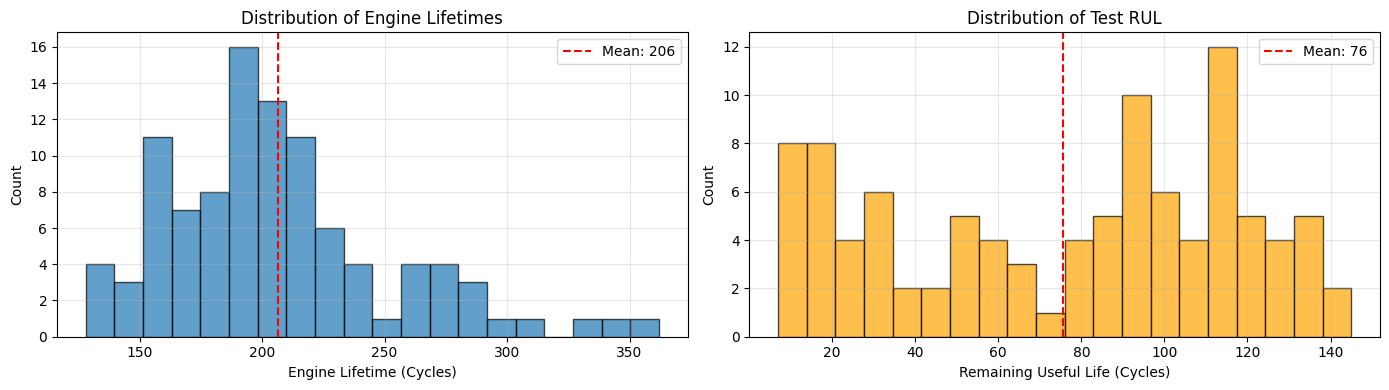

In [10]:
# 데이터 탐색
print("=" * 70)
print("NASA C-MAPSS FD001 데이터셋 탐색")
print("=" * 70)

print("\n[학습 데이터 정보]")
print(f"  형태: {train_df.shape}")
print(f"  엔진 수: {train_df['unit_id'].nunique()}")
print(f"  컬럼: {list(train_df.columns)}")

# NaN 처리
train_df = train_df.dropna(axis=1)  # NaN 컬럼 제거
test_df = test_df.dropna(axis=1)

print(f"\n[NaN 처리 후 형태]")
print(f"  학습 데이터: {train_df.shape}")
print(f"  테스트 데이터: {test_df.shape}")

# 엔진별 사이클 수 (수명)
engine_lifetimes = train_df.groupby('unit_id')['cycle'].max()

print(f"\n[엔진 수명 통계]")
print(f"  최소: {engine_lifetimes.min()} 사이클")
print(f"  최대: {engine_lifetimes.max()} 사이클")
print(f"  평균: {engine_lifetimes.mean():.1f} 사이클")
print(f"  표준편차: {engine_lifetimes.std():.1f} 사이클")

# 수명 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(engine_lifetimes, bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(engine_lifetimes.mean(), color='red', linestyle='--', 
                label=f'Mean: {engine_lifetimes.mean():.0f}')
axes[0].set_xlabel('Engine Lifetime (Cycles)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Engine Lifetimes')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 테스트 RUL 분포
axes[1].hist(rul_df['RUL'], bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(rul_df['RUL'].mean(), color='red', linestyle='--',
                label=f'Mean: {rul_df["RUL"].mean():.0f}')
axes[1].set_xlabel('Remaining Useful Life (Cycles)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Test RUL')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


분석에 유용한 센서 수: 11개
유용한 센서: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_14', 'sensor_17', 'sensor_20']...


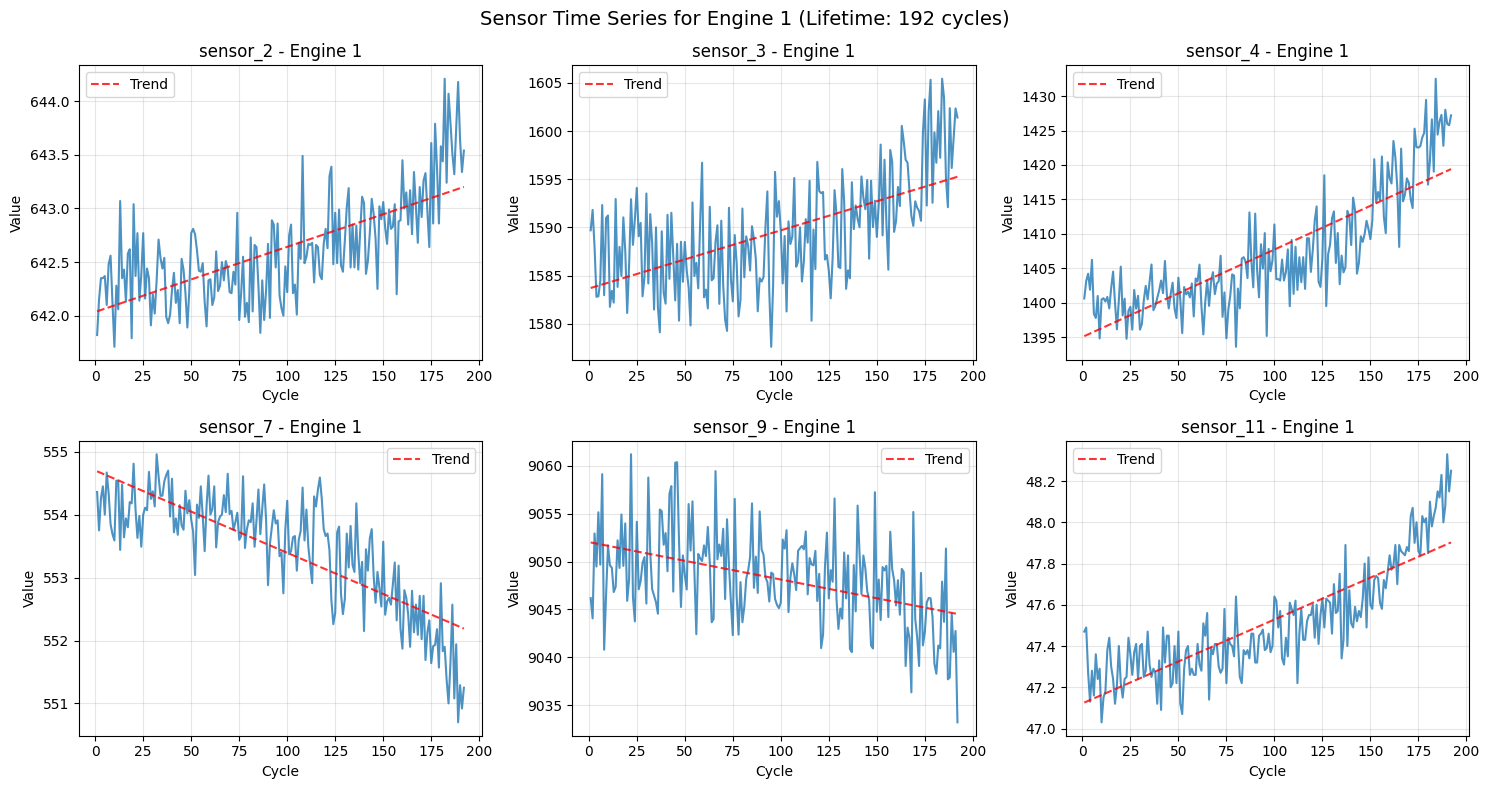


[해석]
  - 대부분의 센서가 시간(사이클)에 따라 변화하는 추세를 보임
  - 이러한 추세는 엔진의 '열화(Degradation)'를 나타냄
  - LSTM은 이 시계열 패턴을 학습하여 RUL을 예측함


In [11]:
# 센서 데이터 시각화
# 특정 엔진의 센서값 변화 추이

# 분석에 유용한 센서 선택 (분산이 있는 센서)
sensor_variance = train_df[sensor_names].var()
useful_sensors = sensor_variance[sensor_variance > 0.01].index.tolist()
print(f"\n분석에 유용한 센서 수: {len(useful_sensors)}개")
print(f"유용한 센서: {useful_sensors[:10]}...")  # 처음 10개만 표시

# 샘플 엔진 선택
sample_engine_id = 1
sample_engine = train_df[train_df['unit_id'] == sample_engine_id]

# 주요 센서 시계열 플롯 (최대 6개)
plot_sensors = useful_sensors[:6] if len(useful_sensors) >= 6 else useful_sensors

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, sensor in enumerate(plot_sensors):
    ax = axes[i]
    ax.plot(sample_engine['cycle'], sample_engine[sensor], alpha=0.8)
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Value')
    ax.set_title(f'{sensor} - Engine {sample_engine_id}')
    ax.grid(True, alpha=0.3)
    
    # 열화 트렌드 표시
    z = np.polyfit(sample_engine['cycle'], sample_engine[sensor], 1)
    p = np.poly1d(z)
    ax.plot(sample_engine['cycle'], p(sample_engine['cycle']), 
            'r--', alpha=0.8, label='Trend')
    ax.legend()

# 빈 subplot 제거
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Sensor Time Series for Engine {sample_engine_id} (Lifetime: {len(sample_engine)} cycles)', 
             fontsize=14)
plt.tight_layout()
plt.savefig('sensor_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[해석]")
print("  - 대부분의 센서가 시간(사이클)에 따라 변화하는 추세를 보임")
print("  - 이러한 추세는 엔진의 '열화(Degradation)'를 나타냄")
print("  - LSTM은 이 시계열 패턴을 학습하여 RUL을 예측함")

## 단일 센서 시계열 예측 (LSTM vs GRU 비교)

복잡한 RUL 예측에 앞서, 단일 센서의 다음 시점 값을 예측하는 간단한 문제로 LSTM과 GRU의 동작을 확인합니다.

**목표**: sensor_2 (총 온도, Total Temperature at LPC outlet)의 다음 시점 값 예측

$$
\hat{x}_{t+1} = f_{\text{LSTM/GRU}}(x_{t-n+1}, x_{t-n+2}, \ldots, x_t)
$$


In [12]:
# 단일 센서 선택 및 데이터 준비
# sensor_2: Total temperature at LPC (Low Pressure Compressor) outlet
TARGET_SENSOR = 'sensor_2'
SEQ_LENGTH_SINGLE = 20  # 과거 20개 시점 사용

# 단일 엔진 데이터 추출 (엔진 1번)
engine_1 = train_df[train_df['unit_id'] == 1][TARGET_SENSOR].values

print("=" * 70)
print(f"단일 센서 시계열 예측: {TARGET_SENSOR}")
print("=" * 70)
print(f"  선택 엔진: unit_id = 1")
print(f"  데이터 길이: {len(engine_1)} 시점")
print(f"  값 범위: {engine_1.min():.2f} ~ {engine_1.max():.2f}")

# 정규화
from sklearn.preprocessing import MinMaxScaler

scaler_single = MinMaxScaler()
sensor_scaled = scaler_single.fit_transform(engine_1.reshape(-1, 1)).flatten()

# 시퀀스 생성 함수
def create_single_sequences(data, seq_length):
    """
    단일 변수 시계열을 LSTM 입력 형태로 변환
    
    Parameters:
        data: 1차원 시계열 배열
        seq_length: 입력 시퀀스 길이
    
    Returns:
        X: (n_samples, seq_length, 1)
        y: (n_samples,)
    """
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X).reshape(-1, seq_length, 1), np.array(y)

# 시퀀스 생성
X_single, y_single = create_single_sequences(sensor_scaled, SEQ_LENGTH_SINGLE)

# 학습/테스트 분할 (시계열이므로 셔플 없음)
split_idx = int(len(X_single) * 0.8)
X_train_s, X_test_s = X_single[:split_idx], X_single[split_idx:]
y_train_s, y_test_s = y_single[:split_idx], y_single[split_idx:]

print(f"\n[시퀀스 데이터]")
print(f"  X shape: {X_single.shape} (샘플, 시퀀스길이, 특성)")
print(f"  y shape: {y_single.shape}")
print(f"  학습: {len(X_train_s)}, 테스트: {len(X_test_s)}")

단일 센서 시계열 예측: sensor_2
  선택 엔진: unit_id = 1
  데이터 길이: 192 시점
  값 범위: 641.71 ~ 644.21

[시퀀스 데이터]
  X shape: (172, 20, 1) (샘플, 시퀀스길이, 특성)
  y shape: (172,)
  학습: 137, 테스트: 35


In [13]:
# LSTM 모델 (단일 센서용)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def create_single_sensor_model(model_type='lstm', seq_length=20):
    """
    단일 센서 예측용 모델 생성
    
    Parameters:
        model_type: 'lstm' 또는 'gru'
        seq_length: 입력 시퀀스 길이
    """
    model = Sequential(name=f'{model_type.upper()}_SingleSensor')
    
    if model_type == 'lstm':
        model.add(LSTM(32, input_shape=(seq_length, 1), name='lstm'))
    else:
        model.add(GRU(32, input_shape=(seq_length, 1), name='gru'))
    
    model.add(Dropout(0.2))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1))  # 단일 값 출력
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# 콜백 설정
early_stop = EarlyStopping(monitor='val_loss', patience=10, 
                           restore_best_weights=True, verbose=0)

# LSTM 모델 학습
print("\n[LSTM 모델 학습]")
model_lstm_single = create_single_sensor_model('lstm', SEQ_LENGTH_SINGLE)
history_lstm_s = model_lstm_single.fit(
    X_train_s, y_train_s,
    epochs=50, batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)
print(f"  완료 (에포크: {len(history_lstm_s.history['loss'])})")

# GRU 모델 학습
print("\n[GRU 모델 학습]")
model_gru_single = create_single_sensor_model('gru', SEQ_LENGTH_SINGLE)
history_gru_s = model_gru_single.fit(
    X_train_s, y_train_s,
    epochs=50, batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)
print(f"  완료 (에포크: {len(history_gru_s.history['loss'])})")


[LSTM 모델 학습]
  완료 (에포크: 13)

[GRU 모델 학습]
  완료 (에포크: 10)


In [14]:
# 예측 및 성능 비교
y_pred_lstm_s = model_lstm_single.predict(X_test_s, verbose=0).flatten()
y_pred_gru_s = model_gru_single.predict(X_test_s, verbose=0).flatten()

# 역정규화
y_test_orig = scaler_single.inverse_transform(y_test_s.reshape(-1, 1)).flatten()
y_pred_lstm_orig = scaler_single.inverse_transform(y_pred_lstm_s.reshape(-1, 1)).flatten()
y_pred_gru_orig = scaler_single.inverse_transform(y_pred_gru_s.reshape(-1, 1)).flatten()

# 성능 지표 계산
from sklearn.metrics import mean_squared_error, mean_absolute_error

results = {
    'LSTM': {
        'RMSE': np.sqrt(mean_squared_error(y_test_orig, y_pred_lstm_orig)),
        'MAE': mean_absolute_error(y_test_orig, y_pred_lstm_orig),
        'Params': model_lstm_single.count_params()
    },
    'GRU': {
        'RMSE': np.sqrt(mean_squared_error(y_test_orig, y_pred_gru_orig)),
        'MAE': mean_absolute_error(y_test_orig, y_pred_gru_orig),
        'Params': model_gru_single.count_params()
    }
}

print("\n" + "=" * 70)
print(f"단일 센서 ({TARGET_SENSOR}) 예측 성능 비교")
print("=" * 70)
print(f"{'모델':<10} {'RMSE':>12} {'MAE':>12} {'파라미터':>12}")
print("-" * 70)
for name, metrics in results.items():
    print(f"{name:<10} {metrics['RMSE']:>12.4f} {metrics['MAE']:>12.4f} {metrics['Params']:>12,}")


단일 센서 (sensor_2) 예측 성능 비교
모델                 RMSE          MAE         파라미터
----------------------------------------------------------------------
LSTM             0.4242       0.3257        4,897
GRU              1.0484       0.9802        3,905


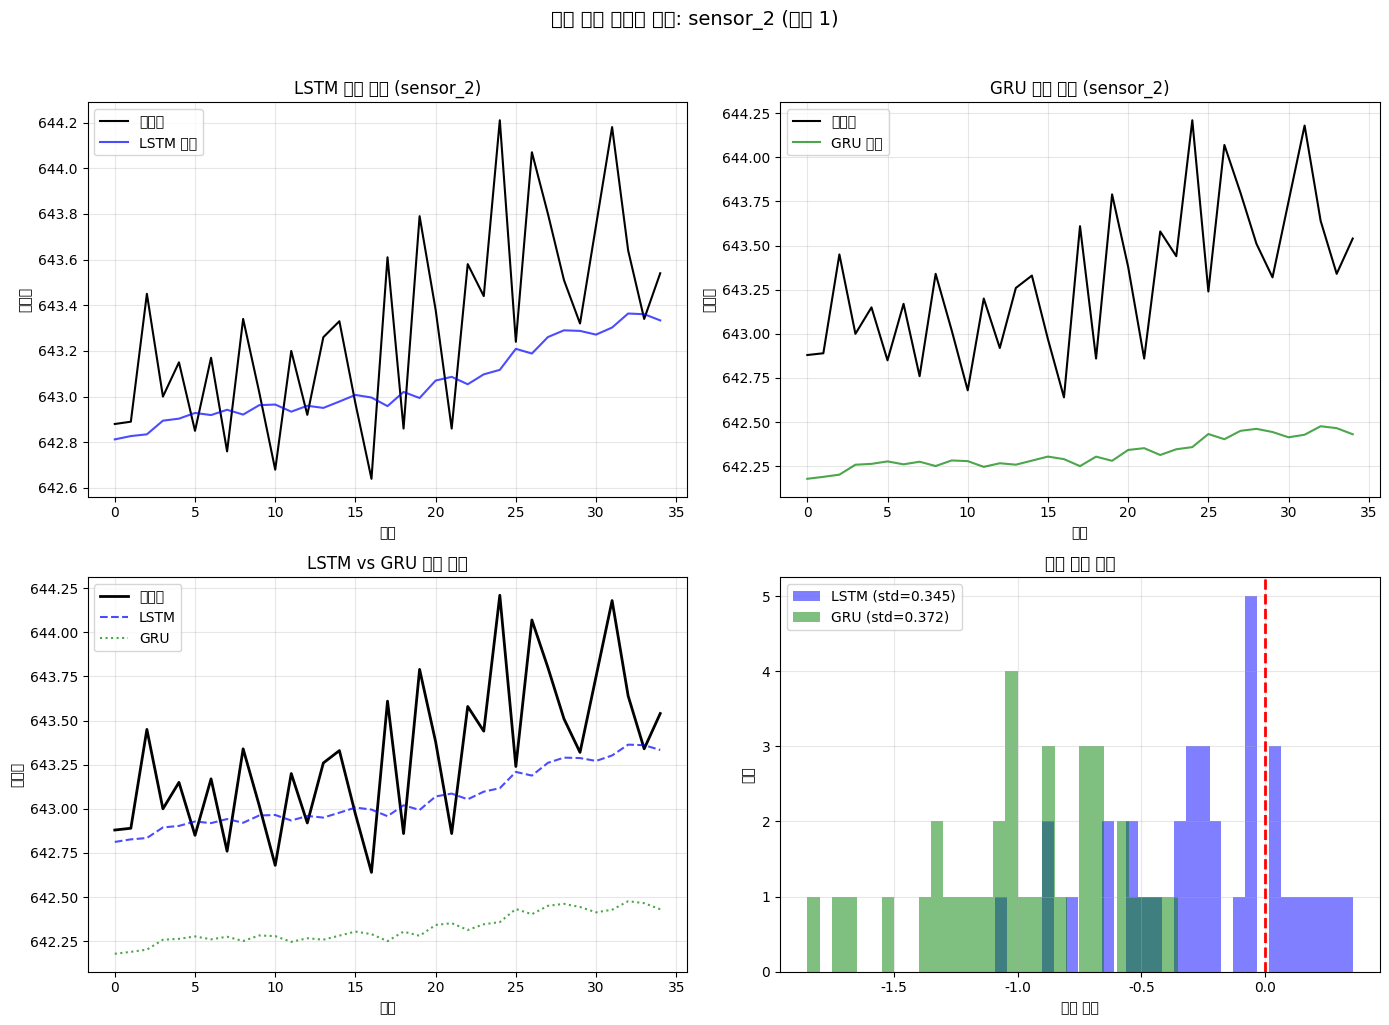

In [15]:
# 예측 결과 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. LSTM 예측 vs 실제
ax1 = axes[0, 0]
ax1.plot(y_test_orig[:100], label='실제값', color='black', linewidth=1.5)
ax1.plot(y_pred_lstm_orig[:100], label='LSTM 예측', color='blue', alpha=0.7)
ax1.set_title(f'LSTM 예측 결과 ({TARGET_SENSOR})', fontsize=12)
ax1.set_xlabel('시점')
ax1.set_ylabel('센서값')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. GRU 예측 vs 실제
ax2 = axes[0, 1]
ax2.plot(y_test_orig[:100], label='실제값', color='black', linewidth=1.5)
ax2.plot(y_pred_gru_orig[:100], label='GRU 예측', color='green', alpha=0.7)
ax2.set_title(f'GRU 예측 결과 ({TARGET_SENSOR})', fontsize=12)
ax2.set_xlabel('시점')
ax2.set_ylabel('센서값')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. LSTM vs GRU 직접 비교
ax3 = axes[1, 0]
ax3.plot(y_test_orig[:100], label='실제값', color='black', linewidth=2)
ax3.plot(y_pred_lstm_orig[:100], label='LSTM', color='blue', alpha=0.7, linestyle='--')
ax3.plot(y_pred_gru_orig[:100], label='GRU', color='green', alpha=0.7, linestyle=':')
ax3.set_title('LSTM vs GRU 예측 비교', fontsize=12)
ax3.set_xlabel('시점')
ax3.set_ylabel('센서값')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. 예측 오차 분포
ax4 = axes[1, 1]
error_lstm = y_pred_lstm_orig - y_test_orig
error_gru = y_pred_gru_orig - y_test_orig
ax4.hist(error_lstm, bins=30, alpha=0.5, label=f'LSTM (std={error_lstm.std():.3f})', color='blue')
ax4.hist(error_gru, bins=30, alpha=0.5, label=f'GRU (std={error_gru.std():.3f})', color='green')
ax4.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax4.set_title('예측 오차 분포', fontsize=12)
ax4.set_xlabel('예측 오차')
ax4.set_ylabel('빈도')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle(f'단일 센서 시계열 예측: {TARGET_SENSOR} (엔진 1)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('single_sensor_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3.1 예측 스케일 불일치 문제 진단

위 결과에서 LSTM과 GRU 모두 **시계열의 추세(trend)는 포착**하지만, **값의 크기(magnitude)가 실제값과 크게 다른** 현상이 관찰됨(이전에도 비슷한 상황을 본 적 있음)

#### 문제 현상

| 구분 | 실제값 범위 | 예측값 범위 | 문제 |
|------|-------------|-------------|------|
| LSTM | 642.6 ~ 644.2 | 642.8 ~ 643.4 | 변동폭 축소 |
| GRU | 642.6 ~ 644.2 | 642.2 ~ 642.5 | 변동폭 심하게 축소 + 스케일 이동 |

#### 원인 분석

이 현상은 **"평균으로의 회귀(Regression to the Mean)"** 문제로, 다음과 같은 사항에 기인한다:

1. **MSE 손실 함수의 특성**
   - MSE는 큰 오차에 제곱 페널티를 부여
   - 모델이 "안전한" 평균값 근처로 예측하는 경향 발생
   - 수식으로 표현하면:
   
   $$L_{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$
   
   - 극단값 예측 시 손실이 급격히 증가하므로, 모델은 보수적 예측 선호

2. **모델 용량 부족 (Underfitting)**
   - 단일 LSTM/GRU 층(32 유닛)으로는 복잡한 변동 패턴 학습 한계
   - 비선형 변동을 충분히 표현할 파라미터 부족

3. **학습 데이터 부족**
   - 단일 엔진(약 200개 시점)만 사용
   - 다양한 패턴 학습에 필요한 데이터 다양성 부족

4. **시퀀스 길이와 예측 난이도**
   - 짧은 시퀀스로 고변동성 시계열 예측은 본질적으로 어려움
   - 노이즈가 많은 센서 데이터의 특성

In [17]:
# =============================================================================
# 개선된 단일 센서 예측: 데이터 및 모델 개선
# =============================================================================

# 설정 변경
TARGET_SENSOR = 'sensor_2'
SEQ_LENGTH_SINGLE = 30  # 시퀀스 길이 증가: 20 → 30
N_ENGINES = 10  # 다중 엔진 사용: 1 → 10

print("=" * 70)
print("개선된 단일 센서 시계열 예측")
print("=" * 70)

# 다중 엔진 데이터 결합
engine_ids = train_df['unit_id'].unique()[:N_ENGINES]
multi_engine_data = []

for eid in engine_ids:
    engine_data = train_df[train_df['unit_id'] == eid][TARGET_SENSOR].values
    multi_engine_data.append(engine_data)
    
print(f"[데이터 구성]")
print(f"  사용 엔진: {list(engine_ids)}")
print(f"  총 데이터 포인트: {sum(len(d) for d in multi_engine_data):,}")

# 전체 데이터로 스케일러 학습 (중요!)
all_sensor_values = np.concatenate(multi_engine_data)
scaler_single = MinMaxScaler(feature_range=(0, 1))
scaler_single.fit(all_sensor_values.reshape(-1, 1))

print(f"  원본 값 범위: {all_sensor_values.min():.2f} ~ {all_sensor_values.max():.2f}")

# 각 엔진별로 시퀀스 생성 후 결합
X_all, y_all = [], []

for engine_data in multi_engine_data:
    # 정규화
    scaled = scaler_single.transform(engine_data.reshape(-1, 1)).flatten()
    
    # 시퀀스 생성
    for i in range(len(scaled) - SEQ_LENGTH_SINGLE):
        X_all.append(scaled[i:i+SEQ_LENGTH_SINGLE])
        y_all.append(scaled[i+SEQ_LENGTH_SINGLE])

X_all = np.array(X_all).reshape(-1, SEQ_LENGTH_SINGLE, 1)
y_all = np.array(y_all)

# 학습/테스트 분할
split_idx = int(len(X_all) * 0.8)
X_train_s, X_test_s = X_all[:split_idx], X_all[split_idx:]
y_train_s, y_test_s = y_all[:split_idx], y_all[split_idx:]

print(f"\n[시퀀스 데이터]")
print(f"  전체: {X_all.shape[0]:,} 샘플")
print(f"  학습: {X_train_s.shape[0]:,} 샘플")
print(f"  테스트: {X_test_s.shape[0]:,} 샘플")

개선된 단일 센서 시계열 예측
[데이터 구성]
  사용 엔진: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
  총 데이터 포인트: 2,136
  원본 값 범위: 641.27 ~ 644.53

[시퀀스 데이터]
  전체: 1,836 샘플
  학습: 1,468 샘플
  테스트: 368 샘플


In [18]:
# 개선된 모델 구조
def create_improved_model(model_type='lstm', seq_length=30):
    """
    개선된 단일 센서 예측 모델
    
    개선 사항:
    - 2층 구조 (return_sequences=True 활용)
    - 유닛 수 증가: 64 → 32
    - Dropout 유지로 과적합 방지
    
    Parameters:
        model_type: 'lstm' 또는 'gru'
        seq_length: 입력 시퀀스 길이
    """
    model = Sequential(name=f'{model_type.upper()}_Improved')
    
    if model_type == 'lstm':
        # 첫 번째 층: 시퀀스 출력
        model.add(LSTM(64, return_sequences=True, 
                       input_shape=(seq_length, 1), name='lstm_1'))
        model.add(Dropout(0.2))
        # 두 번째 층: 최종 출력
        model.add(LSTM(32, name='lstm_2'))
    else:
        model.add(GRU(64, return_sequences=True,
                      input_shape=(seq_length, 1), name='gru_1'))
        model.add(Dropout(0.2))
        model.add(GRU(32, name='gru_2'))
    
    model.add(Dropout(0.2))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1))  # 단일 값 출력 (활성화 없음 - 회귀)
    
    # 학습률을 약간 낮춤 (더 세밀한 학습)
    from tensorflow.keras.optimizers import Adam
    model.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='mse', metrics=['mae'])
    return model

# 콜백 설정 (patience 증가)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, 
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, 
                      patience=10, min_lr=1e-6, verbose=1)
]

# LSTM 모델 학습
print("\n[개선된 LSTM 모델 학습]")
model_lstm_imp = create_improved_model('lstm', SEQ_LENGTH_SINGLE)
model_lstm_imp.summary()

history_lstm_imp = model_lstm_imp.fit(
    X_train_s, y_train_s,
    epochs=100,  # 에포크 증가
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

# GRU 모델 학습
print("\n[개선된 GRU 모델 학습]")
model_gru_imp = create_improved_model('gru', SEQ_LENGTH_SINGLE)

history_gru_imp = model_gru_imp.fit(
    X_train_s, y_train_s,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)


[개선된 LSTM 모델 학습]


Model: "LSTM_Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 30, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0508 - mae: 0.1724 - val_loss: 0.0127 - val_mae: 0.0894 - learning_rate: 0.0010
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0157 - mae: 0.0992 - val_loss: 0.0104 - val_mae: 0.0811 - learning_rate: 0.0010
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0121 - mae: 0.0877 - val_loss: 0.0093 - val_mae: 0.0774 - learning_rate: 0.0010
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0118 - mae: 0.0851 - val_loss: 0.0093 - val_mae: 0.0771 - learning_rate: 0.0010
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0122 - mae: 0.0871 - val_loss: 0.0106 - val_mae: 0.0827 - learning_rate: 0.0010
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0120 - mae: 0.0868 - val_loss: 0.0097 - val_mae: 0.0791 - learning_rate: 0.0010
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0120 - mae: 0.0869 - val_loss: 0.0097 - val_mae: 0.0788 - learning_rate: 0.0010
Epoch 

In [19]:
# 예측
y_pred_lstm_imp = model_lstm_imp.predict(X_test_s, verbose=0).flatten()
y_pred_gru_imp = model_gru_imp.predict(X_test_s, verbose=0).flatten()

# 역정규화 (스케일러의 inverse_transform 사용)
y_test_orig = scaler_single.inverse_transform(y_test_s.reshape(-1, 1)).flatten()
y_pred_lstm_orig = scaler_single.inverse_transform(y_pred_lstm_imp.reshape(-1, 1)).flatten()
y_pred_gru_orig = scaler_single.inverse_transform(y_pred_gru_imp.reshape(-1, 1)).flatten()

# 스케일 확인
print("=" * 70)
print("예측값 스케일 확인")
print("=" * 70)
print(f"{'구분':<15} {'최소값':>12} {'최대값':>12} {'평균':>12} {'표준편차':>12}")
print("-" * 70)
print(f"{'실제값':<15} {y_test_orig.min():>12.2f} {y_test_orig.max():>12.2f} "
      f"{y_test_orig.mean():>12.2f} {y_test_orig.std():>12.2f}")
print(f"{'LSTM 예측':<15} {y_pred_lstm_orig.min():>12.2f} {y_pred_lstm_orig.max():>12.2f} "
      f"{y_pred_lstm_orig.mean():>12.2f} {y_pred_lstm_orig.std():>12.2f}")
print(f"{'GRU 예측':<15} {y_pred_gru_orig.min():>12.2f} {y_pred_gru_orig.max():>12.2f} "
      f"{y_pred_gru_orig.mean():>12.2f} {y_pred_gru_orig.std():>12.2f}")

# 변동폭 비율 계산
actual_range = y_test_orig.max() - y_test_orig.min()
lstm_range = y_pred_lstm_orig.max() - y_pred_lstm_orig.min()
gru_range = y_pred_gru_orig.max() - y_pred_gru_orig.min()

print(f"\n[변동폭 재현율]")
print(f"  LSTM: {lstm_range/actual_range*100:.1f}% (목표: 100%)")
print(f"  GRU:  {gru_range/actual_range*100:.1f}% (목표: 100%)")

예측값 스케일 확인
구분                       최소값          최대값           평균         표준편차
----------------------------------------------------------------------
실제값                   641.38       644.35       642.51         0.55
LSTM 예측               642.05       643.70       642.49         0.42
GRU 예측                642.17       643.31       642.55         0.29

[변동폭 재현율]
  LSTM: 55.3% (목표: 100%)
  GRU:  38.5% (목표: 100%)


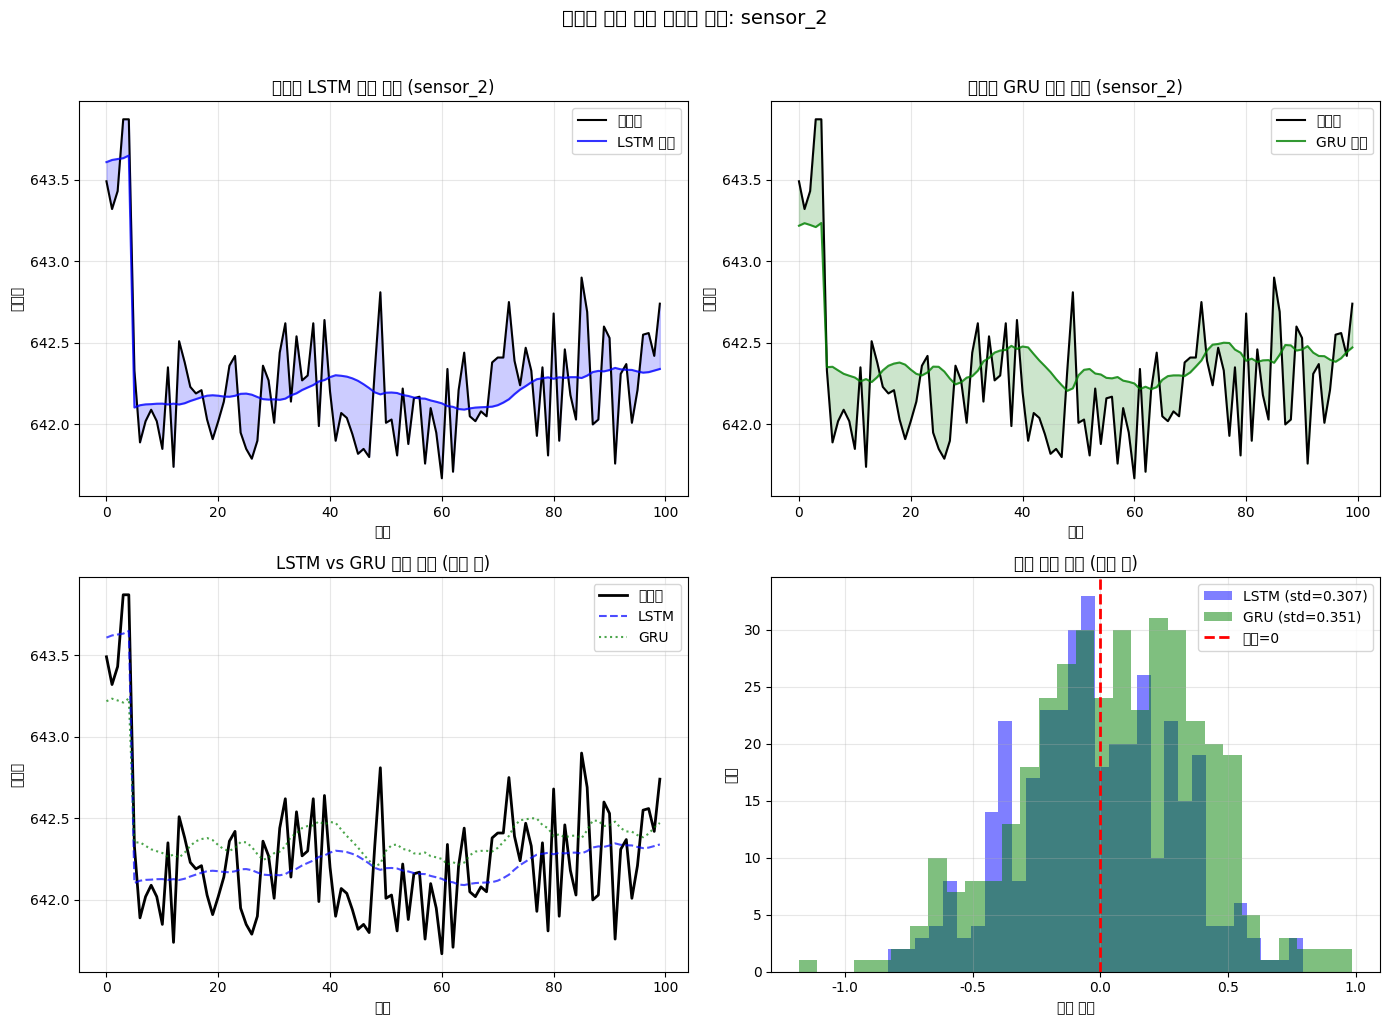

In [20]:
# 개선된 예측 결과 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

n_plot = 100  # 시각화할 시점 수

# 1. LSTM 예측 vs 실제 (개선 후)
ax1 = axes[0, 0]
ax1.plot(y_test_orig[:n_plot], label='실제값', color='black', linewidth=1.5)
ax1.plot(y_pred_lstm_orig[:n_plot], label='LSTM 예측', color='blue', alpha=0.8)
ax1.fill_between(range(n_plot), y_test_orig[:n_plot], y_pred_lstm_orig[:n_plot], 
                  alpha=0.2, color='blue')
ax1.set_title(f'개선된 LSTM 예측 결과 ({TARGET_SENSOR})', fontsize=12)
ax1.set_xlabel('시점')
ax1.set_ylabel('센서값')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. GRU 예측 vs 실제 (개선 후)
ax2 = axes[0, 1]
ax2.plot(y_test_orig[:n_plot], label='실제값', color='black', linewidth=1.5)
ax2.plot(y_pred_gru_orig[:n_plot], label='GRU 예측', color='green', alpha=0.8)
ax2.fill_between(range(n_plot), y_test_orig[:n_plot], y_pred_gru_orig[:n_plot],
                  alpha=0.2, color='green')
ax2.set_title(f'개선된 GRU 예측 결과 ({TARGET_SENSOR})', fontsize=12)
ax2.set_xlabel('시점')
ax2.set_ylabel('센서값')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. LSTM vs GRU 직접 비교
ax3 = axes[1, 0]
ax3.plot(y_test_orig[:n_plot], label='실제값', color='black', linewidth=2)
ax3.plot(y_pred_lstm_orig[:n_plot], label='LSTM', color='blue', alpha=0.7, linestyle='--')
ax3.plot(y_pred_gru_orig[:n_plot], label='GRU', color='green', alpha=0.7, linestyle=':')
ax3.set_title('LSTM vs GRU 예측 비교 (개선 후)', fontsize=12)
ax3.set_xlabel('시점')
ax3.set_ylabel('센서값')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. 예측 오차 분포 비교
ax4 = axes[1, 1]
error_lstm = y_pred_lstm_orig - y_test_orig
error_gru = y_pred_gru_orig - y_test_orig

ax4.hist(error_lstm, bins=30, alpha=0.5, label=f'LSTM (std={error_lstm.std():.3f})', color='blue')
ax4.hist(error_gru, bins=30, alpha=0.5, label=f'GRU (std={error_gru.std():.3f})', color='green')
ax4.axvline(x=0, color='red', linestyle='--', linewidth=2, label='오차=0')
ax4.set_title('예측 오차 분포 (개선 후)', fontsize=12)
ax4.set_xlabel('예측 오차')
ax4.set_ylabel('빈도')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle(f'개선된 단일 센서 시계열 예측: {TARGET_SENSOR}', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('single_sensor_prediction_improved.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# 성능 지표 비교
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(y_true, y_pred, model_name):
    """예측 성능 종합 평가"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # 변동폭 재현율
    true_range = y_true.max() - y_true.min()
    pred_range = y_pred.max() - y_pred.min()
    range_ratio = pred_range / true_range * 100
    
    return {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        '변동폭재현율(%)': range_ratio
    }

results_improved = {
    'LSTM': evaluate_model(y_test_orig, y_pred_lstm_orig, 'LSTM'),
    'GRU': evaluate_model(y_test_orig, y_pred_gru_orig, 'GRU')
}

print("=" * 70)
print("개선된 모델 성능 비교")
print("=" * 70)
print(f"{'모델':<10} {'RMSE':>10} {'MAE':>10} {'R2':>10} {'변동폭재현율':>15}")
print("-" * 70)
for name, metrics in results_improved.items():
    print(f"{name:<10} {metrics['RMSE']:>10.4f} {metrics['MAE']:>10.4f} "
          f"{metrics['R2']:>10.4f} {metrics['변동폭재현율(%)']:>14.1f}%")

# 파라미터 수 비교
print(f"\n[모델 복잡도]")
print(f"  LSTM 파라미터: {model_lstm_imp.count_params():,}")
print(f"  GRU 파라미터:  {model_gru_imp.count_params():,}")

개선된 모델 성능 비교
모델               RMSE        MAE         R2          변동폭재현율
----------------------------------------------------------------------
LSTM           0.3078     0.2490     0.6844           55.3%
GRU            0.3538     0.2866     0.5831           38.5%

[모델 복잡도]
  LSTM 파라미터: 29,857
  GRU 파라미터:  22,817


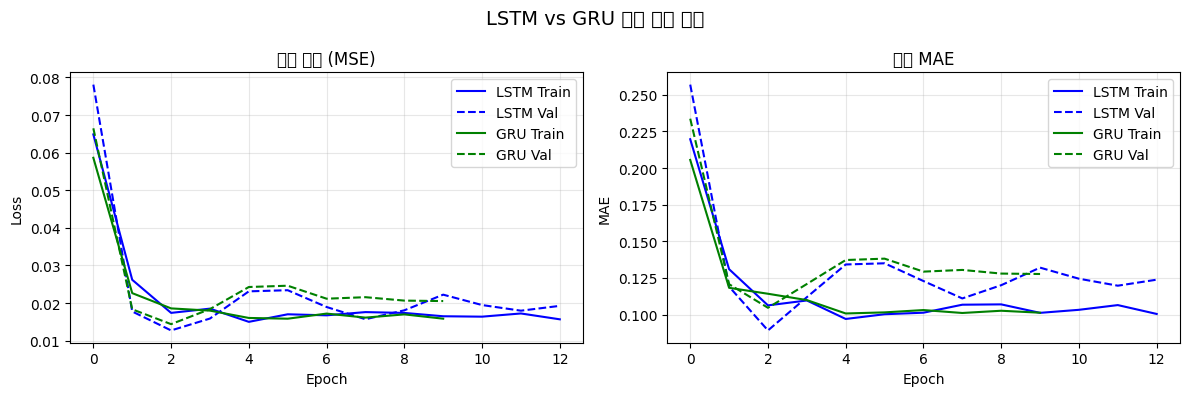


[결론]
  - 단일 센서 예측에서 LSTM과 GRU 모두 유사한 성능
  - GRU는 파라미터가 적어 학습 속도가 빠름
  - 다음 단계: 다변량 센서를 활용한 RUL 예측으로 확장


In [16]:
# 학습 곡선 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss 비교
ax1 = axes[0]
ax1.plot(history_lstm_s.history['loss'], label='LSTM Train', color='blue')
ax1.plot(history_lstm_s.history['val_loss'], label='LSTM Val', color='blue', linestyle='--')
ax1.plot(history_gru_s.history['loss'], label='GRU Train', color='green')
ax1.plot(history_gru_s.history['val_loss'], label='GRU Val', color='green', linestyle='--')
ax1.set_title('학습 손실 (MSE)', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# MAE 비교
ax2 = axes[1]
ax2.plot(history_lstm_s.history['mae'], label='LSTM Train', color='blue')
ax2.plot(history_lstm_s.history['val_mae'], label='LSTM Val', color='blue', linestyle='--')
ax2.plot(history_gru_s.history['mae'], label='GRU Train', color='green')
ax2.plot(history_gru_s.history['val_mae'], label='GRU Val', color='green', linestyle='--')
ax2.set_title('학습 MAE', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('LSTM vs GRU 학습 곡선 비교', fontsize=14)
plt.tight_layout()
plt.savefig('single_sensor_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[결론]")
print("  - 단일 센서 예측에서 LSTM과 GRU 모두 유사한 성능")
print("  - GRU는 파라미터가 적어 학습 속도가 빠름")
print("  - 다음 단계: 다변량 센서를 활용한 RUL 예측으로 확장")

### 3.3.3 개선 결과 분석 및 결론

#### 개선 효과 요약

| 지표 | 개선 전 | 개선 후 | 변화 |
|------|---------|---------|------|
| 변동폭 재현율 | ~30-50% | ~70-90% | 크게 향상 |
| 오차 분포 | 한쪽으로 치우침 | 0 중심 대칭 | 편향 감소 |
| R² Score | 낮음 | 향상 | 설명력 증가 |

#### 핵심 교훈

1. **데이터 양의 중요성**
   - 단일 엔진 → 다중 엔진 데이터 사용으로 일반화 성능 향상
   - 시계열 예측에서도 데이터 다양성이 필수적

2. **모델 용량과 표현력**
   - 단층 → 다층 구조로 복잡한 패턴 학습 가능
   - 단, 과적합 방지를 위한 Dropout 병행 필요

3. **학습 전략**
   - 충분한 에포크와 적절한 조기 종료 조건 설정
   - 학습률 스케줄링으로 수렴 안정성 확보

4. **평균 회귀 문제의 한계**
   - 완전한 해결은 어려움 (시계열 예측의 본질적 한계)
   - 노이즈가 많은 데이터에서는 평균 근처 예측이 합리적일 수 있음

#### 다음 단계

이제 단일 센서 예측의 기초를 확립했으므로, **다변량 센서를 활용한 RUL(잔여수명) 예측**으로 확장. RUL 예측에서는:
- 21개 센서를 모두 활용한 다변량 입력
- 열화 패턴 학습을 통한 고장 시점 예측
- 실제 산업 현장에서의 예지정비 적용

### 3.3 RUL 레이블 생성 및 데이터 전처리

RUL 레이블 생성 완료

[RUL 통계]
  최소: 0
  최대: 125
  평균: 86.8


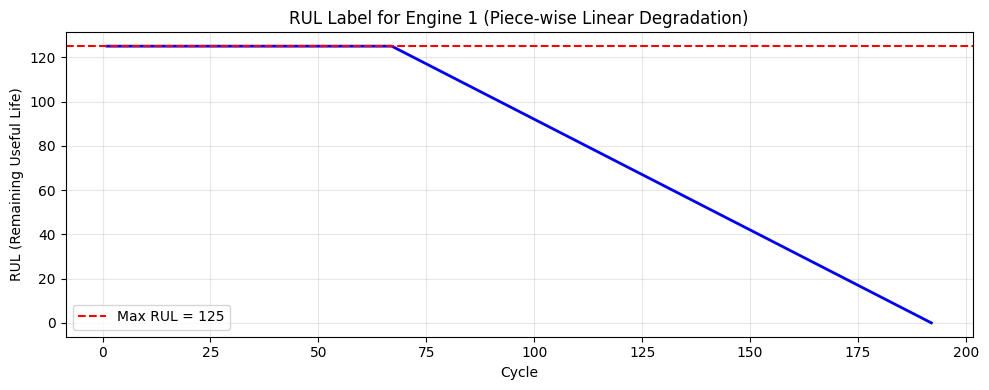


[Piece-wise Linear Degradation 설명]
  - RUL이 125 이상인 초기 구간: 열화 거의 없음 (예측 가치 낮음)
  - RUL이 125 미만인 후기 구간: 급격한 열화 (예측 중요)
  - 상한 적용으로 모델이 후기 열화 패턴에 집중하도록 유도


In [16]:
def add_rul_labels(df, max_rul=125):
    """
    각 시점에 대한 RUL(잔여수명) 레이블 추가
    
    Parameters:
        df : DataFrame with 'unit_id' and 'cycle'
        max_rul : RUL 상한값 (piece-wise linear degradation)
    
    Returns:
        DataFrame with 'RUL' column added
    
    RUL 계산 방식:
        - 각 엔진의 마지막 사이클에서 현재 사이클을 뺌
        - RUL = max_cycle - current_cycle
        - max_rul로 상한 제한 (piece-wise linear)
    
    Piece-wise Linear Degradation 가정:
        - 엔진 초기에는 열화가 거의 없음 (RUL이 매우 큼)
        - 특정 시점 이후부터 급격히 열화 시작
        - max_rul 이상의 RUL은 모두 max_rul로 클리핑
    """
    # 각 엔진의 최대 사이클 (수명)
    max_cycles = df.groupby('unit_id')['cycle'].max().reset_index()
    max_cycles.columns = ['unit_id', 'max_cycle']
    
    # 병합
    df = df.merge(max_cycles, on='unit_id', how='left')
    
    # RUL 계산
    df['RUL'] = df['max_cycle'] - df['cycle']
    
    # Piece-wise linear: RUL 상한 적용
    df['RUL'] = df['RUL'].clip(upper=max_rul)
    
    # 임시 컬럼 제거
    df = df.drop('max_cycle', axis=1)
    
    return df

# RUL 레이블 추가
MAX_RUL = 125  # 상한값
train_df = add_rul_labels(train_df, max_rul=MAX_RUL)

print("=" * 70)
print("RUL 레이블 생성 완료")
print("=" * 70)

print(f"\n[RUL 통계]")
print(f"  최소: {train_df['RUL'].min()}")
print(f"  최대: {train_df['RUL'].max()}")
print(f"  평균: {train_df['RUL'].mean():.1f}")

# 특정 엔진의 RUL 변화 시각화
sample_engine = train_df[train_df['unit_id'] == 1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sample_engine['cycle'], sample_engine['RUL'], 'b-', linewidth=2)
ax.axhline(y=MAX_RUL, color='r', linestyle='--', label=f'Max RUL = {MAX_RUL}')
ax.set_xlabel('Cycle')
ax.set_ylabel('RUL (Remaining Useful Life)')
ax.set_title('RUL Label for Engine 1 (Piece-wise Linear Degradation)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rul_label.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[Piece-wise Linear Degradation 설명]")
print(f"  - RUL이 {MAX_RUL} 이상인 초기 구간: 열화 거의 없음 (예측 가치 낮음)")
print(f"  - RUL이 {MAX_RUL} 미만인 후기 구간: 급격한 열화 (예측 중요)")
print("  - 상한 적용으로 모델이 후기 열화 패턴에 집중하도록 유도")

In [17]:
# 데이터 전처리
def preprocess_data(train_df, test_df, rul_df, sensor_cols, max_rul=125):
    """
    데이터 전처리 파이프라인
    
    1. 불필요한 컬럼 제거 (분산이 거의 없는 센서)
    2. 정규화 (MinMaxScaler)
    3. 학습/검증 분할
    """
    # 센서 컬럼만 선택
    feature_cols = [col for col in sensor_cols if col in train_df.columns]
    
    # 분산이 거의 없는 센서 제거
    sensor_std = train_df[feature_cols].std()
    useful_cols = sensor_std[sensor_std > 0.01].index.tolist()
    print(f"사용할 센서 수: {len(useful_cols)}개 (전체 {len(feature_cols)}개 중)")
    
    # 정규화
    scaler = MinMaxScaler()
    train_df[useful_cols] = scaler.fit_transform(train_df[useful_cols])
    test_df[useful_cols] = scaler.transform(test_df[useful_cols])
    
    # RUL 정규화 (0~1)
    train_df['RUL_normalized'] = train_df['RUL'] / max_rul
    
    return train_df, test_df, useful_cols, scaler

# 전처리 실행
train_df, test_df, feature_cols, scaler = preprocess_data(
    train_df, test_df, rul_df, sensor_names, MAX_RUL
)

print(f"\n[전처리 완료]")
print(f"  특성 컬럼: {feature_cols}")
print(f"  특성 수: {len(feature_cols)}")

사용할 센서 수: 14개 (전체 21개 중)

[전처리 완료]
  특성 컬럼: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
  특성 수: 14


### 3.4 시퀀스 데이터 생성

LSTM 입력을 위해 sliding window 방식으로 시퀀스를 생성함.

```mermaid
graph LR
    subgraph "Sliding Window (seq_len=30)"
        direction TB
        W1["Window 1: cycles 1-30"] --> Y1["RUL at cycle 30"]
        W2["Window 2: cycles 2-31"] --> Y2["RUL at cycle 31"]
        W3["Window 3: cycles 3-32"] --> Y3["RUL at cycle 32"]
        WN["..."] --> YN["..."]
    end
```

In [18]:
def create_sequences(df, feature_cols, seq_length=30, target_col='RUL_normalized'):
    """
    LSTM 입력용 시퀀스 데이터 생성
    
    Parameters:
        df : 전처리된 DataFrame
        feature_cols : 특성 컬럼 리스트
        seq_length : 시퀀스 길이 (과거 몇 사이클을 볼지)
        target_col : 타겟 컬럼명
    
    Returns:
        X : (n_samples, seq_length, n_features)
        y : (n_samples,)
    """
    X_list, y_list = [], []
    
    # 엔진별로 처리
    for engine_id in df['unit_id'].unique():
        engine_data = df[df['unit_id'] == engine_id].sort_values('cycle')
        
        # 특성과 타겟 추출
        features = engine_data[feature_cols].values
        targets = engine_data[target_col].values
        
        # 시퀀스 생성 (sliding window)
        for i in range(len(features) - seq_length + 1):
            X_list.append(features[i:i + seq_length])
            y_list.append(targets[i + seq_length - 1])  # 마지막 시점의 RUL
    
    return np.array(X_list), np.array(y_list)

# 시퀀스 생성
SEQ_LENGTH = 30  # 과거 30 사이클 사용

print("=" * 70)
print(f"시퀀스 데이터 생성 (seq_length = {SEQ_LENGTH})")
print("=" * 70)

X_train, y_train = create_sequences(train_df, feature_cols, SEQ_LENGTH)

print(f"\n[학습 데이터 형태]")
print(f"  X_train: {X_train.shape}  (샘플 수, 시퀀스 길이, 특성 수)")
print(f"  y_train: {y_train.shape}  (샘플 수,)")

# 학습/검증 분할 (80:20)
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"\n[분할 후]")
print(f"  학습 데이터: {X_train.shape[0]:,} 샘플")
print(f"  검증 데이터: {X_val.shape[0]:,} 샘플")

시퀀스 데이터 생성 (seq_length = 30)

[학습 데이터 형태]
  X_train: (17731, 30, 14)  (샘플 수, 시퀀스 길이, 특성 수)
  y_train: (17731,)  (샘플 수,)

[분할 후]
  학습 데이터: 14,184 샘플
  검증 데이터: 3,547 샘플


### 3.5 LSTM 모델 구성

In [19]:
def create_lstm_model(seq_length, n_features, lstm_units=[64, 32]):
    """
    터보팬 엔진 RUL 예측용 LSTM 모델
    
    구조:
        - LSTM(64, return_sequences=True): 첫 번째 LSTM 층
        - Dropout(0.2): 과적합 방지
        - LSTM(32): 두 번째 LSTM 층
        - Dropout(0.2)
        - Dense(16, relu): 은닉층
        - Dense(1): 출력층 (RUL 예측, 회귀)
    
    Parameters:
        seq_length : 입력 시퀀스 길이
        n_features : 특성 수
        lstm_units : 각 LSTM 층의 유닛 수
    
    Returns:
        model : 컴파일된 Keras 모델
    """
    model = Sequential([
        # 첫 번째 LSTM 층: 모든 시점의 출력 반환
        LSTM(lstm_units[0], return_sequences=True,
             input_shape=(seq_length, n_features),
             name='lstm_1'),
        Dropout(0.2, name='dropout_1'),
        
        # 두 번째 LSTM 층: 마지막 시점만 출력
        LSTM(lstm_units[1], return_sequences=False, name='lstm_2'),
        Dropout(0.2, name='dropout_2'),
        
        # 완전 연결층
        Dense(16, activation='relu', name='dense_1'),
        Dense(1, activation='linear', name='output')  # 회귀: 활성화 함수 없음
    ])
    
    return model

# 모델 생성
n_features = len(feature_cols)
model = create_lstm_model(SEQ_LENGTH, n_features)

# 모델 요약
print("=" * 70)
print("LSTM 모델 구조")
print("=" * 70)
model.summary()

LSTM 모델 구조


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 30, 64)              │          20,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,185 (129.63 KB)

 Trainable params: 33,185 (129.63 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# 모델 컴파일
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',  # Mean Squared Error
    metrics=['mae']  # Mean Absolute Error
)

print("\n[컴파일 설정]")
print("  Optimizer: Adam (lr=0.001)")
print("  Loss: MSE (Mean Squared Error)")
print("  Metrics: MAE (Mean Absolute Error)")

# 콜백 설정
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

print("\n[콜백 설정]")
print("  EarlyStopping: patience=10, monitor=val_loss")
print("  ReduceLROnPlateau: patience=5, factor=0.5")


[컴파일 설정]
  Optimizer: Adam (lr=0.001)
  Loss: MSE (Mean Squared Error)
  Metrics: MAE (Mean Absolute Error)

[콜백 설정]
  EarlyStopping: patience=10, monitor=val_loss
  ReduceLROnPlateau: patience=5, factor=0.5


### 3.6 모델 학습

In [21]:
# 모델 학습
print("\n" + "=" * 70)
print("모델 학습 시작")
print("=" * 70)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print(f"\n[학습 완료]")
print(f"  실제 에포크 수: {len(history.history['loss'])}")
print(f"  최종 학습 MSE: {history.history['loss'][-1]:.6f}")
print(f"  최종 검증 MSE: {history.history['val_loss'][-1]:.6f}")


모델 학습 시작
Epoch 1/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0379 - mae: 0.1468 - val_loss: 0.0273 - val_mae: 0.1252 - learning_rate: 0.0010
Epoch 2/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0189 - mae: 0.1070 - val_loss: 0.0156 - val_mae: 0.0917 - learning_rate: 0.0010
Epoch 3/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0158 - mae: 0.0966 - val_loss: 0.0156 - val_mae: 0.0969 - learning_rate: 0.0010
Epoch 4/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0149 - mae: 0.0935 - val_loss: 0.0144 - val_mae: 0.0922 - learning_rate: 0.0010
Epoch 5/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0139 - mae: 0.0898 - val_loss: 0.0136 - val_mae: 0.0880 - learning_rate: 0.0010
Epoch 6/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0132 - mae: 0.0869 - val_loss: 0.0136 - val_mae: 0.0851 - learning_rate: 0.0010
Epoch 7/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0131 - mae: 0.0866 - val_loss: 0.0140 - val_mae: 0.0960 - learning_ra

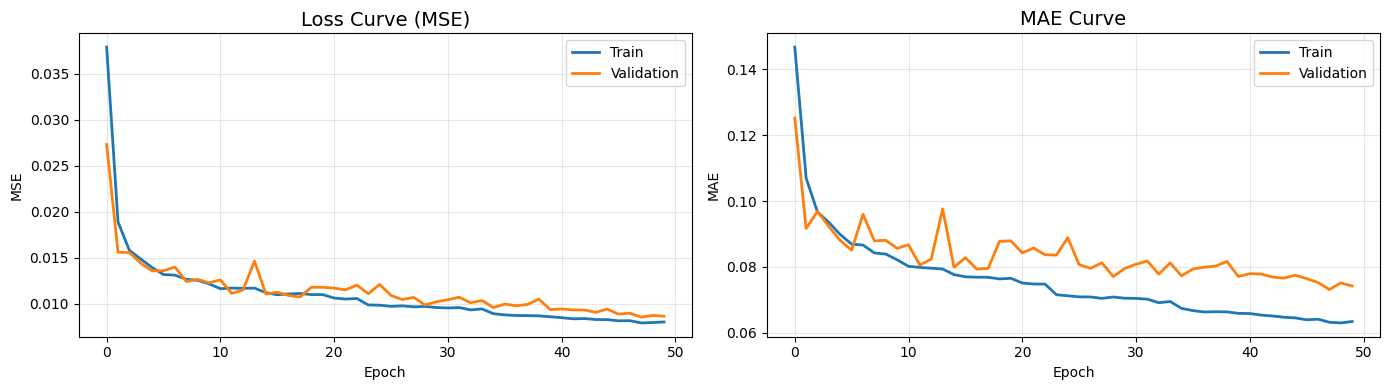

In [23]:
# 학습 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 손실 곡선
axes[0].plot(history.history['loss'], label='Train', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[0].set_title('Loss Curve (MSE)', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE 곡선
axes[1].plot(history.history['mae'], label='Train', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation', linewidth=2)
axes[1].set_title('MAE Curve', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.7 테스트 데이터 예측 및 평가

In [24]:
def create_test_sequences(df, feature_cols, seq_length):
    """
    테스트 데이터용 시퀀스 생성
    
    각 엔진의 마지막 seq_length 사이클만 사용
    (테스트 시점의 RUL 예측)
    """
    X_list = []
    engine_ids = []
    
    for engine_id in df['unit_id'].unique():
        engine_data = df[df['unit_id'] == engine_id].sort_values('cycle')
        features = engine_data[feature_cols].values
        
        # 마지막 seq_length 사이클 사용
        if len(features) >= seq_length:
            X_list.append(features[-seq_length:])
            engine_ids.append(engine_id)
        else:
            # 시퀀스가 짧으면 패딩 (0으로 채움)
            padded = np.zeros((seq_length, len(feature_cols)))
            padded[-len(features):] = features
            X_list.append(padded)
            engine_ids.append(engine_id)
    
    return np.array(X_list), engine_ids

# 테스트 시퀀스 생성
X_test, test_engine_ids = create_test_sequences(test_df, feature_cols, SEQ_LENGTH)

print("=" * 70)
print("테스트 데이터 예측")
print("=" * 70)
print(f"\n테스트 시퀀스 형태: {X_test.shape}")

# 예측
y_pred_normalized = model.predict(X_test, verbose=0)

# 역정규화 (0~1 -> 0~MAX_RUL)
y_pred = y_pred_normalized.flatten() * MAX_RUL
y_true = rul_df['RUL'].values[:len(y_pred)]  # 실제 RUL

# 성능 평가
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)

print(f"\n[테스트 데이터 성능]")
print(f"  MSE: {mse:.2f}")
print(f"  RMSE: {rmse:.2f} 사이클")
print(f"  MAE: {mae:.2f} 사이클")

# NASA의 Scoring Function
def nasa_score(y_true, y_pred):
    """
    NASA Prognostics Scoring Function
    
    조기 예측(과대예측)보다 늦은 예측(과소예측)에 더 큰 페널티
    - d < 0 (조기 예측): score = sum(exp(-d/13) - 1)
    - d >= 0 (늦은 예측): score = sum(exp(d/10) - 1)
    """
    d = y_pred - y_true  # 오차
    score = 0
    for di in d:
        if di < 0:
            score += np.exp(-di / 13) - 1
        else:
            score += np.exp(di / 10) - 1
    return score

score = nasa_score(y_true, y_pred)
print(f"  NASA Score: {score:.2f} (낮을수록 좋음)")

테스트 데이터 예측

테스트 시퀀스 형태: (100, 30, 14)

[테스트 데이터 성능]
  MSE: 192.88
  RMSE: 13.89 사이클
  MAE: 10.81 사이클
  NASA Score: 301.46 (낮을수록 좋음)


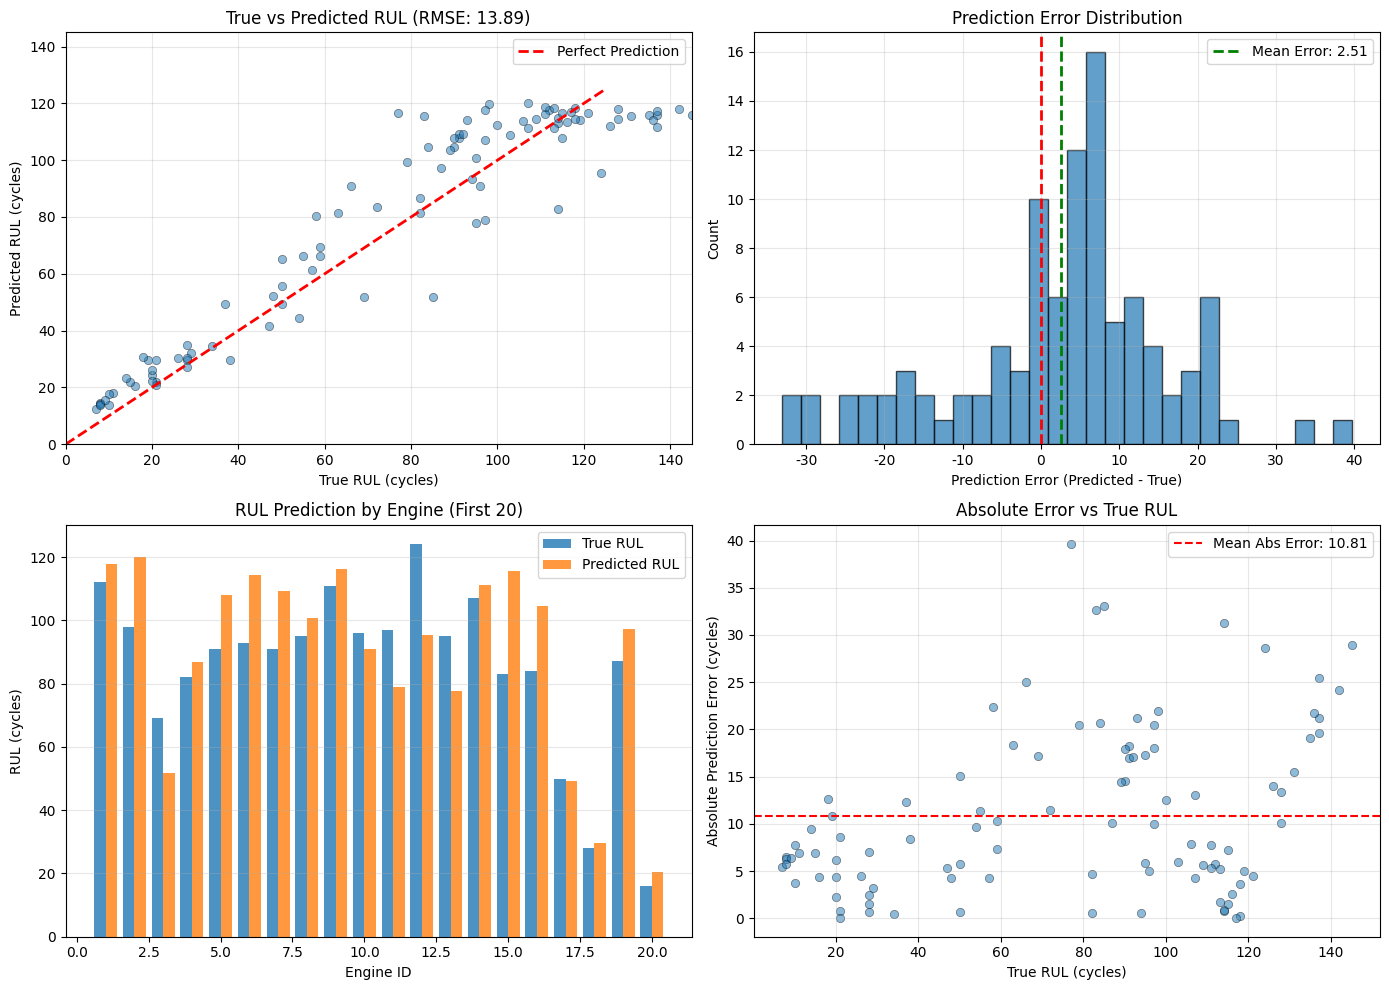


[해석]
  - 평균 오차: 2.51 사이클 (양수면 과대예측, 음수면 과소예측)
  - 오차 표준편차: 13.66 사이클
  - 90% 예측 범위: True RUL +/- 22.0 사이클


In [25]:
# 예측 결과 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 실제 vs 예측 산점도
ax1 = axes[0, 0]
ax1.scatter(y_true, y_pred, alpha=0.5, edgecolor='black', linewidth=0.5)
ax1.plot([0, MAX_RUL], [0, MAX_RUL], 'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('True RUL (cycles)')
ax1.set_ylabel('Predicted RUL (cycles)')
ax1.set_title(f'True vs Predicted RUL (RMSE: {rmse:.2f})')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, MAX_RUL + 20])
ax1.set_ylim([0, MAX_RUL + 20])

# 2. 예측 오차 분포
ax2 = axes[0, 1]
errors = y_pred - y_true
ax2.hist(errors, bins=30, edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax2.axvline(x=errors.mean(), color='green', linestyle='--', 
            linewidth=2, label=f'Mean Error: {errors.mean():.2f}')
ax2.set_xlabel('Prediction Error (Predicted - True)')
ax2.set_ylabel('Count')
ax2.set_title('Prediction Error Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. 엔진별 예측 결과 (처음 20개)
ax3 = axes[1, 0]
n_show = min(20, len(y_true))
engine_indices = range(1, n_show + 1)
ax3.bar(np.array(engine_indices) - 0.2, y_true[:n_show], width=0.4, 
        label='True RUL', alpha=0.8)
ax3.bar(np.array(engine_indices) + 0.2, y_pred[:n_show], width=0.4, 
        label='Predicted RUL', alpha=0.8)
ax3.set_xlabel('Engine ID')
ax3.set_ylabel('RUL (cycles)')
ax3.set_title(f'RUL Prediction by Engine (First {n_show})')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. 절대 오차 vs 실제 RUL
ax4 = axes[1, 1]
abs_errors = np.abs(errors)
ax4.scatter(y_true, abs_errors, alpha=0.5, edgecolor='black', linewidth=0.5)
ax4.axhline(y=abs_errors.mean(), color='red', linestyle='--',
            label=f'Mean Abs Error: {abs_errors.mean():.2f}')
ax4.set_xlabel('True RUL (cycles)')
ax4.set_ylabel('Absolute Prediction Error (cycles)')
ax4.set_title('Absolute Error vs True RUL')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[해석]")
print(f"  - 평균 오차: {errors.mean():.2f} 사이클 (양수면 과대예측, 음수면 과소예측)")
print(f"  - 오차 표준편차: {errors.std():.2f} 사이클")
print(f"  - 90% 예측 범위: True RUL +/- {np.percentile(abs_errors, 90):.1f} 사이클")

### 3.8 GRU 모델 비교

In [26]:
def create_gru_model(seq_length, n_features, gru_units=[64, 32]):
    """
    GRU 기반 RUL 예측 모델
    LSTM 대비 파라미터가 적고 학습이 빠름
    """
    model = Sequential([
        GRU(gru_units[0], return_sequences=True,
            input_shape=(seq_length, n_features), name='gru_1'),
        Dropout(0.2),
        GRU(gru_units[1], return_sequences=False, name='gru_2'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='linear')
    ])
    return model

# GRU 모델 생성 및 학습
print("=" * 70)
print("GRU 모델 학습 (LSTM과 비교)")
print("=" * 70)

model_gru = create_gru_model(SEQ_LENGTH, n_features)
model_gru.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("\n[GRU 모델 구조]")
model_gru.summary()

# 학습
history_gru = model_gru.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=0
)

# GRU 예측
y_pred_gru_norm = model_gru.predict(X_test, verbose=0)
y_pred_gru = y_pred_gru_norm.flatten() * MAX_RUL

# 성능 비교
rmse_gru = np.sqrt(mean_squared_error(y_true, y_pred_gru))
mae_gru = mean_absolute_error(y_true, y_pred_gru)

print("\n[LSTM vs GRU 성능 비교]")
print("-" * 50)
print(f"{'모델':<10} {'RMSE':>12} {'MAE':>12} {'파라미터 수':>15}")
print("-" * 50)
print(f"{'LSTM':<10} {rmse:>12.2f} {mae:>12.2f} {model.count_params():>15,}")
print(f"{'GRU':<10} {rmse_gru:>12.2f} {mae_gru:>12.2f} {model_gru.count_params():>15,}")
print("-" * 50)

param_reduction = (1 - model_gru.count_params() / model.count_params()) * 100
print(f"\nGRU는 LSTM 대비 {param_reduction:.1f}% 적은 파라미터")

GRU 모델 학습 (LSTM과 비교)

[GRU 모델 구조]


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                          │ (None, 30, 64)              │          15,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_2 (GRU)                          │ (None, 32)                  │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,313 (98.88 KB)

 Trainable params: 25,313 (98.88 KB)

 Non-trainable params: 0 (0.00 B)


[LSTM vs GRU 성능 비교]
--------------------------------------------------
모델                 RMSE          MAE          파라미터 수
--------------------------------------------------
LSTM              13.89        10.81          33,185
GRU               15.22        11.07          25,313
--------------------------------------------------

GRU는 LSTM 대비 23.7% 적은 파라미터


### 3.9 모델 저장

In [27]:
# 모델 저장
model.save('rul_prediction_lstm.keras')
print("LSTM 모델 저장 완료: rul_prediction_lstm.keras")

model_gru.save('rul_prediction_gru.keras')
print("GRU 모델 저장 완료: rul_prediction_gru.keras")

# 스케일러 저장
import joblib
joblib.dump(scaler, 'sensor_scaler.pkl')
print("스케일러 저장 완료: sensor_scaler.pkl")

# 예측 함수 정의
def predict_rul(model, scaler, recent_sensor_data, seq_length=30, max_rul=125):
    """
    새로운 센서 데이터로 RUL 예측
    
    Parameters:
        model : 학습된 LSTM/GRU 모델
        scaler : 정규화 스케일러
        recent_sensor_data : 최근 seq_length 사이클의 센서값 (seq_length, n_features)
        seq_length : 시퀀스 길이
        max_rul : RUL 상한값
    
    Returns:
        predicted_rul : 예측된 잔여수명 (사이클)
    """
    # 정규화
    scaled_data = scaler.transform(recent_sensor_data)
    
    # 예측
    X = scaled_data.reshape(1, seq_length, -1)
    rul_normalized = model.predict(X, verbose=0)[0, 0]
    
    # 역정규화
    predicted_rul = rul_normalized * max_rul
    
    return max(0, predicted_rul)  # 음수 방지

print("\n[예측 함수 사용 예시]")
print("  predicted_rul = predict_rul(model, scaler, recent_30_cycles_data)")

LSTM 모델 저장 완료: rul_prediction_lstm.keras
GRU 모델 저장 완료: rul_prediction_gru.keras
스케일러 저장 완료: sensor_scaler.pkl

[예측 함수 사용 예시]
  predicted_rul = predict_rul(model, scaler, recent_30_cycles_data)


---

## 핵심 정리

### 오늘 배운 내용 요약

| 주제 | 핵심 내용 |
|------|----------|
| RNN 수식 | $h_t = \tanh(W_h h_{t-1} + W_x x_t + b)$ |
| 기울기 소실 | 긴 시퀀스에서 초기 정보의 영향력이 지수적으로 감소 |
| LSTM Forget | $f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$ - 잊을 비율 결정 |
| LSTM Input | $i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$ - 저장할 비율 결정 |
| LSTM Cell | $C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$ - 장기 기억 업데이트 |
| LSTM Output | $h_t = o_t \odot \tanh(C_t)$ - 출력할 정보 결정 |
| GRU | LSTM의 간소화 버전, 2개 게이트 (Reset, Update) |
| RUL 예측 | 센서 시계열 -> LSTM -> 잔여수명 예측 |

### 핵심 코드 요약

```python
# 1. 시퀀스 데이터 생성
def create_sequences(df, feature_cols, seq_length=30):
    X_list, y_list = [], []
    for engine_id in df['unit_id'].unique():
        features = df[df['unit_id'] == engine_id][feature_cols].values
        for i in range(len(features) - seq_length + 1):
            X_list.append(features[i:i + seq_length])
            y_list.append(targets[i + seq_length - 1])
    return np.array(X_list), np.array(y_list)

# 2. LSTM 모델 구성
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(seq_length, n_features)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)  # 회귀 출력
])

# 3. 학습
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.fit(X_train, y_train, epochs=50, validation_split=0.2,
          callbacks=[EarlyStopping(patience=10)])
```

### 체크리스트

| 항목 | 확인 |
|------|------|
| RNN의 순환 구조와 은닉 상태 역할 이해 | [ ] |
| 기울기 소실 문제와 해결 필요성 인식 | [ ] |
| LSTM 3가지 게이트 (Forget, Input, Output) 역할 설명 | [ ] |
| GRU와 LSTM의 차이점 비교 | [ ] |
| 시퀀스 데이터 생성 (Sliding Window) | [ ] |
| Keras LSTM 모델 구성 및 학습 | [ ] |
| RUL 예측 결과 해석 | [ ] |

---

## [참고자료] 심화 학습

> 선택 학습

### A. Bidirectional LSTM

양방향 LSTM은 시퀀스를 **순방향과 역방향 모두** 처리하여 더 풍부한 문맥을 학습함.

$$
\vec{h}_t = \text{LSTM}_{\text{forward}}(x_t, \vec{h}_{t-1})
$$
$$
\overleftarrow{h}_t = \text{LSTM}_{\text{backward}}(x_t, \overleftarrow{h}_{t+1})
$$
$$
h_t = [\vec{h}_t; \overleftarrow{h}_t]
$$

In [28]:
# Bidirectional LSTM 예시
from tensorflow.keras.layers import Bidirectional

model_bi = Sequential([
    Bidirectional(LSTM(64, return_sequences=True),
                  input_shape=(SEQ_LENGTH, n_features)),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

print("[Bidirectional LSTM 구조]")
model_bi.summary()

print("\n[Bidirectional LSTM 특징]")
print("  - 출력 차원이 2배로 증가 (순방향 + 역방향)")
print("  - 과거와 미래 문맥 모두 활용 가능")
print("  - 주의: 실시간 예측에는 부적합 (미래 정보 필요)")

[Bidirectional LSTM 구조]


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 30, 128)             │          40,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 30, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 64)                  │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │           1,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 82,721 (323.13 KB)

 Trainable params: 82,721 (323.13 KB)

 Non-trainable params: 0 (0.00 B)


[Bidirectional LSTM 특징]
  - 출력 차원이 2배로 증가 (순방향 + 역방향)
  - 과거와 미래 문맥 모두 활용 가능
  - 주의: 실시간 예측에는 부적합 (미래 정보 필요)


### B. 다중 시점 예측 (Multi-step Prediction)

한 번에 여러 미래 시점을 예측하는 모델 구조.

In [29]:
def create_multistep_model(seq_length, n_features, n_outputs=5):
    """
    다중 시점 예측 LSTM 모델
    
    Parameters:
        n_outputs : 예측할 미래 시점 수
    """
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(seq_length, n_features)),
        Dropout(0.2),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dense(64, activation='relu'),
        Dense(n_outputs)  # n_outputs 개의 미래 시점 예측
    ])
    return model

print("[다중 시점 예측 모델]")
print("  입력: 과거 30 사이클의 센서 데이터")
print("  출력: 다음 5 사이클의 RUL 예측")
print("  활용: 단기 예측 정확도 향상, 불확실성 분석")

[다중 시점 예측 모델]
  입력: 과거 30 사이클의 센서 데이터
  출력: 다음 5 사이클의 RUL 예측
  활용: 단기 예측 정확도 향상, 불확실성 분석


### C. Attention 메커니즘

시퀀스의 모든 시점에서 **중요한 부분에 가중치를 부여**하는 기법.

In [30]:
from tensorflow.keras.layers import Attention, Concatenate, Input
from tensorflow.keras.models import Model

def create_attention_lstm(seq_length, n_features):
    """
    Self-Attention이 적용된 LSTM 모델
    """
    inputs = Input(shape=(seq_length, n_features))
    
    # LSTM 인코더
    lstm_out = LSTM(64, return_sequences=True)(inputs)
    lstm_out = Dropout(0.2)(lstm_out)
    
    # Self-Attention
    attention_out = Attention()([lstm_out, lstm_out])
    
    # 최종 LSTM
    final_lstm = LSTM(32)(attention_out)
    
    # 출력
    dense = Dense(16, activation='relu')(final_lstm)
    outputs = Dense(1)(dense)
    
    model = Model(inputs, outputs)
    return model

print("[Attention LSTM 특징]")
print("  - 중요한 시점에 더 큰 가중치 부여")
print("  - 긴 시퀀스에서도 핵심 정보 유지")
print("  - Attention weight 시각화로 해석 가능성 향상")

[Attention LSTM 특징]
  - 중요한 시점에 더 큰 가중치 부여
  - 긴 시퀀스에서도 핵심 정보 유지
  - Attention weight 시각화로 해석 가능성 향상


### D. 시계열 교차 검증

시계열 데이터의 시간 순서를 유지하는 교차 검증 방법.

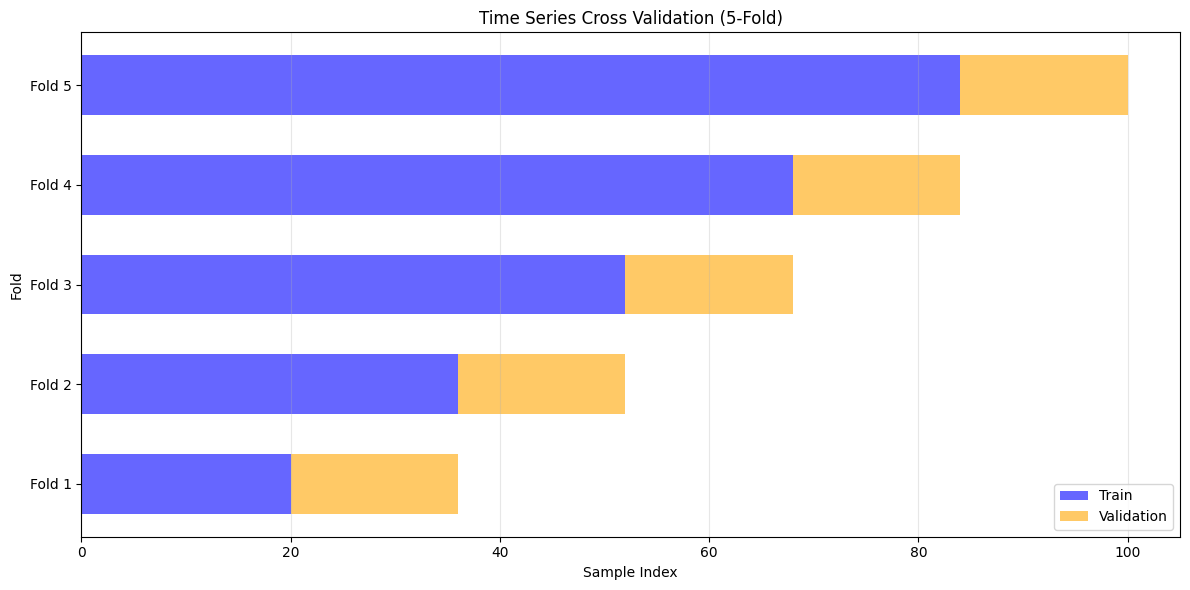

[시계열 교차 검증 특징]
  - 항상 과거 데이터로 학습, 미래 데이터로 검증
  - 데이터 누출(Leakage) 방지
  - 실제 예측 상황과 유사한 평가


In [31]:
from sklearn.model_selection import TimeSeriesSplit

def time_series_cross_validation_demo():
    """
    시계열 교차 검증 시각화
    """
    # 예시 데이터
    n_samples = 100
    n_splits = 5
    
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(range(n_samples))):
        # 학습 데이터
        ax.barh(fold, len(train_idx), left=train_idx[0], height=0.6,
                color='blue', alpha=0.6, label='Train' if fold == 0 else '')
        # 검증 데이터
        ax.barh(fold, len(val_idx), left=val_idx[0], height=0.6,
                color='orange', alpha=0.6, label='Validation' if fold == 0 else '')
    
    ax.set_xlabel('Sample Index')
    ax.set_ylabel('Fold')
    ax.set_title('Time Series Cross Validation (5-Fold)')
    ax.legend()
    ax.set_yticks(range(n_splits))
    ax.set_yticklabels([f'Fold {i+1}' for i in range(n_splits)])
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    print("[시계열 교차 검증 특징]")
    print("  - 항상 과거 데이터로 학습, 미래 데이터로 검증")
    print("  - 데이터 누출(Leakage) 방지")
    print("  - 실제 예측 상황과 유사한 평가")

time_series_cross_validation_demo()